
# Capítulo 4 — Modelagem passo a passo, sem “caixa-preta”

Este notebook foi preparado para continuar o TCC a partir do ponto em que o notebook `01_eda_ptbr.ipynb` parou.

## Objetivo

Construir, entender e avaliar uma cadeia experimental completa:

1. definir **o que estamos prevendo e em que momento a previsão acontece**;
2. evitar vazamento temporal (*data leakage*);
3. criar baselines históricos fortes;
4. treinar modelos de Machine Learning para a permanência total no porto;
5. avaliar o erro geral e a cauda da distribuição;
6. estimar quantis de risco (P50, P90 e P95);
7. traduzir os quantis em um **exercício de estoque de segurança / capital de giro**;
8. gerar tabelas e gráficos que possam ser usados no Capítulo 4.

> **Princípio central:** em cada etapa, rode a célula, observe a saída e só avance quando conseguir explicar em palavras o que aconteceu.



## 0. Antes de modelar: qual é o instante da previsão?

Para este TCC, a interpretação mais coerente é:

> **No instante em que a embarcação chega ao porto (`arrival_port_ts`), queremos estimar quanto tempo ela permanecerá no porto.**

Isso define a regra mais importante do experimento:

### Uma feature só pode ser usada se estivesse disponível no momento da chegada.

Consequências práticas:

- `port`, região, estado, calendário e tipo de operação: em princípio podem ser conhecidos na chegada;
- variáveis climáticas **históricas** (1, 3 e 7 datas observadas anteriores): são seguras, com a ressalva de raros saltos de calendário na série climática;
- clima realizado do próprio dia completo pode conter informação posterior ao horário de chegada;
- `arrivals_same_day_port` contém chegadas posteriores no mesmo dia e, portanto, pode vazar futuro;
- `arrivals_prev_day_port` e `arrivals_prev_7d_avg_port` são `REQUIRES_REDESIGN`: não vazam futuro, mas usam datas observadas com chegada, não um calendário diário completo com zeros;
- médias de duração das “20 chamadas anteriores por ordem de chegada” também merecem cautela: uma chamada que chegou antes pode ainda não ter terminado quando a chamada atual chega.

Por isso, começaremos com um **conjunto conservador de features sem vazamento evidente**. Depois, se necessário, reconstruiremos as features operacionais de forma mais rigorosa.


In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurações do pandas para exibir todas as colunas e ajustar a largura do display
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    mean_pinball_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..")
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "eda_base.parquet"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "t_total_port_stay_h"
DATE_COL = "arrival_port_ts"

df = pd.read_parquet(DATA_FILE)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL, TARGET]).copy()

print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]:,}")
print(f"Período: {df[DATE_COL].min()} até {df[DATE_COL].max()}")


Linhas: 129,625
Colunas: 126
Período: 2023-01-01 00:08:00 até 2025-12-31 23:00:00



### 0.1 Faça uma checagem rápida da variável-alvo

O ponto principal é lembrar por que a mediana é uma referência importante:

- a média é puxada para cima pelos casos extremos;
- a mediana representa melhor o comportamento típico;
- RMSE muito maior que MAE é um sinal de que erros extremos importam.


In [2]:

target_summary = df[TARGET].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)
target_summary


count    129625.000000
mean         71.103869
std          97.116162
min           0.016667
50%          38.416667
75%          80.833333
90%         163.083333
95%         253.733333
99%         527.852667
max        1280.083333
Name: t_total_port_stay_h, dtype: float64


## 1. Feature engineering seguro

### 1.1 Variáveis cíclicas

Hora, dia da semana e mês são variáveis circulares.  
23h está perto de 0h, e dezembro está perto de janeiro.

Em vez de deixar o modelo interpretar esses números como uma linha reta, criamos seno e cosseno.


In [3]:

df["arrival_hour_sin"] = np.sin(2 * np.pi * df["arrival_hour"] / 24)
df["arrival_hour_cos"] = np.cos(2 * np.pi * df["arrival_hour"] / 24)

df["arrival_dow_sin"] = np.sin(2 * np.pi * df["arrival_dayofweek"] / 7)
df["arrival_dow_cos"] = np.cos(2 * np.pi * df["arrival_dayofweek"] / 7)

df["arrival_month_sin"] = np.sin(2 * np.pi * (df["arrival_month"] - 1) / 12)
df["arrival_month_cos"] = np.cos(2 * np.pi * (df["arrival_month"] - 1) / 12)



### 1.2 Conjunto conservador de features

Nesta primeira versão **não usaremos**:

- `arrivals_same_day_port`;
- `arrivals_prev_day_port` (`REQUIRES_REDESIGN`);
- `arrivals_prev_7d_avg_port` (`REQUIRES_REDESIGN`);
- clima observado do próprio dia;
- `avg_wait_prev_20_calls_port`;
- `avg_operation_prev_20_calls_port`;
- `std_wait_prev_20_calls_port`.

Essas variáveis podem ser úteis, mas precisam ser reconstruídas ou justificadas conforme o instante da previsão. Em especial, as contagens defasadas de chegada devem ser recalculadas sobre um calendário diário completo por porto, preenchendo dias sem chegada com zero antes de aplicar lag e janelas móveis.


In [4]:

CATEGORICAL_FEATURES = [
    "port",
    "region",
    "state",
    "arrival_shift",
    "arrival_season",
]

NUMERICAL_FEATURES = [
    "arrival_quarter",
    "arrival_weekofyear",
    "arrival_is_weekend",
    "arrival_hour_sin",
    "arrival_hour_cos",
    "arrival_dow_sin",
    "arrival_dow_cos",
    "arrival_month_sin",
    "arrival_month_cos",

    # REQUIRES_REDESIGN: as contagens defasadas de chegadas atuais
    # usam datas observadas com chegada, não calendário diário completo.

    # Clima histórico
    "rain_sum_prev_1d",
    "precipitation_sum_prev_1d",
    "wind_speed_10m_max_prev_1d",
    "wind_gusts_10m_max_prev_1d",
    "temperature_2m_mean_prev_1d",
    "rain_sum_prev_3d",
    "precipitation_hours_prev_3d",
    "temperature_2m_mean_prev_3d",
    "wind_speed_10m_max_prev_3d",
    "wind_gusts_10m_max_prev_3d",
    "rain_sum_prev_7d",
    "precipitation_hours_prev_7d",
    "temperature_2m_mean_prev_7d",
    "wind_speed_10m_max_prev_7d",
    "wind_gusts_10m_max_prev_7d",
]

OPERATION_FEATURES = sorted(
    c for c in df.columns if c.startswith("op_")
)

CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]
NUMERICAL_FEATURES = [c for c in NUMERICAL_FEATURES if c in df.columns]
OPERATION_FEATURES = [c for c in OPERATION_FEATURES if c in df.columns]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES + OPERATION_FEATURES

print(f"Categóricas: {len(CATEGORICAL_FEATURES)}")
print(f"Numéricas: {len(NUMERICAL_FEATURES)}")
print(f"Flags de operação: {len(OPERATION_FEATURES)}")
print(f"Total de features antes do One-Hot: {len(FEATURES)}")


Categóricas: 5
Numéricas: 24
Flags de operação: 17
Total de features antes do One-Hot: 46


In [5]:
OPERATION_FEATURES

['op_abastecimento_bunker',
 'op_arribada',
 'op_carga',
 'op_descarga',
 'op_desembarque_passageiros',
 'op_embarque_passageiros',
 'op_fundeio',
 'op_fundeio_ship_to_ship',
 'op_navio_estado_com_operacao_comercial',
 'op_navio_estado_marinha_brasil',
 'op_navio_estado_sem_operacao_comercial',
 'op_offshore',
 'op_reparo_manutencao',
 'op_retirada_residuos_com_operacao_comercial',
 'op_retirada_residuos_sem_operacao_comercial',
 'op_solicitacao_certificado',
 'op_tipo_operacao_nao_mapeado']


## 2. Divisão temporal

O notebook anterior usou:

- treino: até 30/06/2024;
- validação: 01/07/2024 a 31/12/2024;
- teste: 2025.

Como os resultados de 2025 **já foram consultados nos baselines**, o conjunto de 2025 não é mais um holdout totalmente “cego”.

Para aumentar o rigor, esta versão separa:

- **Treino:** 2023 até 30/06/2024;
- **Validação:** 01/07/2024 a 31/12/2024;
- **Calibração / desenvolvimento:** 01/01/2025 a 30/06/2025;
- **Teste final:** 01/07/2025 a 31/12/2025.

### Como usar

- treino + validação: escolha de modelo;
- calibração: checagem de quantis e decisões finais;
- teste final: abrir apenas quando a metodologia estiver congelada.

> Se você decidir manter o desenho original do texto, pode voltar a usar 2025 inteiro como teste, mas registre essa limitação metodológica.


In [6]:

train_df = df[df[DATE_COL] < "2024-07-01"].copy()

val_df = df[
    (df[DATE_COL] >= "2024-07-01")
    & (df[DATE_COL] < "2025-01-01")
].copy()

cal_df = df[
    (df[DATE_COL] >= "2025-01-01")
    & (df[DATE_COL] < "2025-07-01")
].copy()

test_df = df[df[DATE_COL] >= "2025-07-01"].copy()

split_summary = pd.DataFrame({
    "dataset": ["train", "validation", "calibration", "final_test"],
    "rows": [len(train_df), len(val_df), len(cal_df), len(test_df)],
    "min_date": [
        train_df[DATE_COL].min(),
        val_df[DATE_COL].min(),
        cal_df[DATE_COL].min(),
        test_df[DATE_COL].min(),
    ],
    "max_date": [
        train_df[DATE_COL].max(),
        val_df[DATE_COL].max(),
        cal_df[DATE_COL].max(),
        test_df[DATE_COL].max(),
    ],
})

print(split_summary)


       dataset   rows            min_date            max_date
0        train  66909 2023-01-01 00:08:00 2024-06-30 23:30:00
1   validation  20362 2024-07-01 00:00:00 2024-12-31 22:40:00
2  calibration  21352 2025-01-01 00:05:00 2025-06-30 23:40:00
3   final_test  21002 2025-07-01 00:00:00 2025-12-31 23:00:00



## 3. Funções de avaliação

Para regressão de permanência:

- **MAE:** erro médio em horas; será a métrica principal;
- **RMSE:** dá peso maior a erros muito grandes;
- **MedAE:** mostra o erro do caso “típico”;
- **RMSLE:** compara erros em escala logarítmica e reduz a dominância de valores extremos.


In [7]:

def rmsle(y_true, y_pred):
    y_true = np.clip(np.asarray(y_true), 0, None)
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))

def regression_metrics(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "medae": median_absolute_error(y_true, y_pred),
        "rmsle": rmsle(y_true, y_pred),
    }

def add_result(results, model_name, dataset_name, y_true, y_pred):
    row = {
        "model": model_name,
        "dataset": dataset_name,
        **regression_metrics(y_true, y_pred),
    }
    results.append(row)
    return row



## 4. Baselines históricos

### 4.1 Mediana global

Pergunta respondida:

> “Se eu ignorar todo o contexto, qual é o tempo típico histórico?”


In [8]:

results = []

global_median = train_df[TARGET].median()
pred = np.repeat(global_median, len(val_df))

add_result(
    results,
    "baseline_global_median",
    "validation",
    val_df[TARGET],
    pred,
)

print(results)


[{'model': 'baseline_global_median', 'dataset': 'validation', 'mae': 56.36327882002423, 'rmse': 112.0850157358452, 'medae': 23.933333333333337, 'rmsle': 1.1003884559748442}]



### 4.2 Mediana por porto

Pergunta:

> “Dado o porto em que a embarcação chegou, qual foi a permanência típica histórica nesse porto?”


In [9]:
def group_median_prediction(train, scoring, group_cols, min_group_size=1):
    global_median = train[TARGET].median()

    # Agrupamos os dados de treino pelas colunas do grupo e calculamos a mediana e o tamanho do grupo
    stats = (
        train.groupby(group_cols, dropna=False)[TARGET]
        .agg(["median", "count"])
        .reset_index()
    )

    # Se o tamanho do grupo for menor que min_group_size, definimos a mediana como NaN
    stats.loc[stats["count"] < min_group_size, "median"] = np.nan

    # Mesclamos as estatísticas calculadas com os dados de pontuação (scoring) para obter as medianas correspondentes
    scored = scoring[group_cols].copy()
    scored = scored.merge(
        stats[group_cols + ["median"]],
        on=group_cols,
        how="left",
    )

    # Preenchemos os valores ausentes com a mediana global e retornamos como um array numpy
    return scored["median"].fillna(global_median).to_numpy()

pred_port = group_median_prediction(
    train_df,
    val_df,
    ["port"],
)

add_result(
    results,
    "baseline_median_by_port",
    "validation",
    val_df[TARGET],
    pred_port,
)

print(results)


[{'model': 'baseline_global_median', 'dataset': 'validation', 'mae': 56.36327882002423, 'rmse': 112.0850157358452, 'medae': 23.933333333333337, 'rmsle': 1.1003884559748442}, {'model': 'baseline_median_by_port', 'dataset': 'validation', 'mae': 52.10191369544577, 'rmse': 108.12844578521434, 'medae': 20.666666666666668, 'rmsle': 0.9822516369310347}]



### 4.3 Baseline hierárquico: porto + combinação de operação → porto → global

No notebook anterior, 73% dos grupos `porto + operation_type` tinham menos de 30 observações no treino.

Isso significa que aceitar qualquer combinação, mesmo com 1 ou 2 exemplos, pode produzir uma “mediana” instável.

A regra hierárquica é:

1. usar `porto + operation_type` somente se o grupo tiver pelo menos 30 casos;
2. senão, usar a mediana do porto;
3. se o porto também não existir, usar a mediana global.


In [10]:
def hierarchical_median_prediction(
    train,
    scoring,
    primary_cols,
    fallback_cols,
    min_group_size=30,
):
    # Calcular a mediana global do alvo no conjunto de treino
    global_median = train[TARGET].median()

    # Agrupamos os dados de treino pelas colunas primárias e calculamos a mediana e o tamanho do grupo
    primary = (
        train.groupby(primary_cols, dropna=False)[TARGET]
        .agg(["median", "count"])
        .reset_index()
    )
    # Se o tamanho do grupo for menor que min_group_size, definimos a mediana como NaN
    primary = primary[primary["count"] >= min_group_size]
    primary = primary[primary_cols + ["median"]].rename(
        columns={"median": "primary_median"}
    )

    # Agrupamos os dados de treino pelas colunas de fallback e calculamos a mediana e o tamanho do grupo
    fallback = (
        train.groupby(fallback_cols, dropna=False)[TARGET]
        .agg(["median", "count"])
        .reset_index()
    )
    # Se o tamanho do grupo for menor que min_group_size, definimos a mediana como NaN
    fallback = fallback[fallback["count"] >= min_group_size]
    fallback = fallback[fallback_cols + ["median"]].rename(
        columns={"median": "fallback_median"}
    )

    # Mesclamos as estatísticas calculadas com os dados de pontuação (scoring) para obter as medianas correspondentes
    out = scoring[primary_cols].copy()
    out = out.merge(primary, on=primary_cols, how="left")
    out = out.merge(fallback, on=fallback_cols, how="left")

    # Preenchemos os valores ausentes com a mediana global e retornamos como um array numpy
    return (
        out["primary_median"]
        .fillna(out["fallback_median"])
        .fillna(global_median)
        .to_numpy()
    )

pred_hier = hierarchical_median_prediction(
    train_df,
    val_df,
    primary_cols=["port", "operation_type"],
    fallback_cols=["port"],
    min_group_size=30,
)

add_result(
    results,
    "baseline_hierarchical_port_operation",
    "validation",
    val_df[TARGET],
    pred_hier,
)

baseline_results = pd.DataFrame(results)
baseline_results["mae_improvement_vs_global_pct"] = (
    (baseline_results.loc[0, "mae"] - baseline_results["mae"])
    / baseline_results.loc[0, "mae"]
    * 100
)

print(baseline_results)


                                  model     dataset        mae        rmse      medae     rmsle  mae_improvement_vs_global_pct
0                baseline_global_median  validation  56.363279  112.085016  23.933333  1.100388                       0.000000
1               baseline_median_by_port  validation  52.101914  108.128446  20.666667  0.982252                       7.560534
2  baseline_hierarchical_port_operation  validation  47.864135  100.996561  19.283333  0.895052                      15.079223



### O que você deve conseguir explicar antes de seguir

- Por que a mediana global é um baseline?
- Por que segmentar por porto melhora a previsão?
- Por que `porto + operação` pode melhorar ainda mais?
- Por que grupos muito pequenos precisam de fallback?
- Por que estamos avaliando primeiro na validação, e não no teste final?



## 5. Pré-processamento para Machine Learning

Temos dois tipos principais de variável:

- categóricas → preenchimento + One-Hot Encoding;
- numéricas → preenchimento pela mediana.

Para o Ridge, também aplicaremos `StandardScaler`, porque a regularização depende da escala das variáveis.

Para modelos de árvore, a escala numérica não é necessária.


In [11]:
def build_preprocessor(scale_numeric=False):
    # Para o pipeline de pré-processamento de variáveis numéricas, usamos a mediana para valores vazios
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median")),
    ]
    # Também podemos opcionalmente aplicar padronização (StandardScaler)
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)

    # Já para o pipeline de pré-processamento de variáveis categóricas, usamos a moda para valores vazios e One-Hot Encoding
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, NUMERICAL_FEATURES + OPERATION_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ])

X_train = train_df[FEATURES].copy()
X_val = val_df[FEATURES].copy()

y_train = train_df[TARGET].copy()
y_val = val_df[TARGET].copy()



## 6. Modelo 1 — Ridge na escala logarítmica

O Ridge é a primeira referência de Machine Learning porque representa uma
relação linear regularizada entre as features e a variável-alvo.

### Por que modelar `log(1 + permanência)`?

A permanência portuária é positiva, fortemente assimétrica e possui cauda longa.
Se treinássemos diretamente nas horas, observações extremas poderiam dominar o
ajuste do modelo.

Por isso, durante o treinamento usamos:

$$
\log(1 + t_{total})
$$

e depois convertemos a previsão novamente para horas com `expm1`.

### Regularização

O Ridge adiciona uma penalização aos coeficientes:

$$
\text{erro} + \alpha \sum_j \beta_j^2
$$

O parâmetro `alpha` controla a intensidade dessa regularização:

- valores pequenos deixam o modelo mais próximo de uma regressão linear comum;
- valores grandes reduzem mais fortemente os coeficientes.

Neste experimento testaremos apenas alguns valores pré-definidos de `alpha`.
A escolha será feita **exclusivamente pelo menor MAE no conjunto de validação**.

O objetivo não é realizar uma busca extensa de hiperparâmetros, mas verificar
se a intensidade da regularização altera de forma relevante o desempenho do
modelo.


In [12]:
# Valores simples e espaçados em escala logarítmica.
# Não estamos fazendo uma busca exaustiva de hiperparâmetros:
# o objetivo é apenas verificar a sensibilidade do Ridge à regularização.
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_rows = []
ridge_models = {}
ridge_predictions = {}

for alpha in RIDGE_ALPHAS:

    model = Pipeline([
        (
            "preprocessor",
            build_preprocessor(scale_numeric=True),
        ),
        (
            "model",
            Ridge(alpha=alpha),
        ),
    ])

    # O Ridge é ajustado sobre log(1 + permanência).
    # Isso reduz a influência da cauda longa durante o treinamento.
    model.fit(
        X_train,
        np.log1p(y_train),
    )

    # Voltamos da escala logarítmica para horas.
    pred = np.expm1(
        model.predict(X_val)
    )

    # Permanências negativas não têm interpretação física.
    pred = np.clip(
        pred,
        0,
        None,
    )

    metrics = regression_metrics(
        y_val,
        pred,
    )

    ridge_rows.append({
        "alpha": alpha,
        **metrics,
    })

    ridge_models[alpha] = model
    ridge_predictions[alpha] = pred


ridge_comparison = (
    pd.DataFrame(ridge_rows)
    .sort_values(
        ["mae", "rmse"],
        ascending=True,
    )
    .reset_index(drop=True)
)

print(ridge_comparison)


    alpha        mae        rmse      medae     rmsle
0   10.00  53.120483  130.497274  20.332378  0.939143
1    1.00  53.207798  132.224791  20.376659  0.939386
2    0.10  53.252847  132.755336  20.389783  0.939655
3    0.01  53.258489  132.883747  20.385203  0.939695
4  100.00  53.270567  130.902816  20.260219  0.943664


### 6.1 Escolha do `alpha`

O melhor `alpha` será aquele com menor MAE no período de validação.

É importante observar que a validação pode ser usada para essa decisão.
O teste final permanece fechado e não participa da escolha.

Também observaremos RMSE, MedAE e RMSLE para garantir que uma pequena melhora
no MAE não esteja acompanhada de deterioração importante nas demais métricas.

In [13]:
best_alpha = float(
    ridge_comparison.iloc[0]["alpha"]
)

ridge = ridge_models[best_alpha]
pred_ridge_val = ridge_predictions[best_alpha]

print(
    f"Melhor alpha pela validação: {best_alpha}"
)

Melhor alpha pela validação: 10.0


In [14]:
# Remove um resultado anterior do Ridge caso esta célula
# seja executada novamente durante a exploração do notebook.
results = [
    row
    for row in results
    if row["model"] != "ridge_log_target"
]

add_result(
    results,
    "ridge_log_target",
    "validation",
    y_val,
    pred_ridge_val,
)

ridge_vs_baselines = (
    pd.DataFrame(results)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(ridge_vs_baselines)

                                  model     dataset        mae        rmse      medae     rmsle
0  baseline_hierarchical_port_operation  validation  47.864135  100.996561  19.283333  0.895052
1               baseline_median_by_port  validation  52.101914  108.128446  20.666667  0.982252
2                      ridge_log_target  validation  53.120483  130.497274  20.332378  0.939143
3                baseline_global_median  validation  56.363279  112.085016  23.933333  1.100388


In [15]:
best_baseline_mae = (
    ridge_vs_baselines[
        ridge_vs_baselines["model"]
        .str.startswith("baseline")
    ]["mae"]
    .min()
)

ridge_mae = regression_metrics(
    y_val,
    pred_ridge_val,
)["mae"]

ridge_improvement_vs_best_baseline = (
    (best_baseline_mae - ridge_mae)
    / best_baseline_mae
    * 100
)

print(
    f"MAE do melhor baseline: {best_baseline_mae:.2f} h"
)

print(
    f"MAE do Ridge: {ridge_mae:.2f} h"
)

print(
    "Ganho do Ridge vs melhor baseline: "
    f"{ridge_improvement_vs_best_baseline:.2f}%"
)

MAE do melhor baseline: 47.86 h
MAE do Ridge: 53.12 h
Ganho do Ridge vs melhor baseline: -10.98%


### 6.2 Inspeção dos coeficientes

O Ridge é um modelo linear. Portanto, depois do ajuste podemos observar os
coeficientes associados às features transformadas.

Coeficientes positivos estão associados a aumento da previsão na escala
logarítmica da permanência; coeficientes negativos estão associados a redução.

Como as variáveis numéricas foram padronizadas, seus coeficientes ficam mais
comparáveis entre si.

Ainda assim, a magnitude dos coeficientes deve ser interpretada com cautela:

- não representa causalidade;
- categorias do One-Hot são indicadores binários;
- variáveis correlacionadas podem dividir informação entre seus coeficientes;
- o target foi modelado em escala logarítmica.

O objetivo aqui é compreender o comportamento do modelo, e não produzir uma
interpretação causal.

In [16]:
ridge_preprocessor = (
    ridge.named_steps["preprocessor"]
)

ridge_model = (
    ridge.named_steps["model"]
)

feature_names = (
    ridge_preprocessor
    .get_feature_names_out()
)

ridge_coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": ridge_model.coef_,
})

ridge_coefficients["abs_coefficient"] = (
    ridge_coefficients["coefficient"].abs()
)

ridge_coefficients = (
    ridge_coefficients
    .sort_values(
        "abs_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

ridge_coefficients.head(20)

,feature,coefficient,abs_coefficient
0,cat__port_BR997001,-2.252258,2.252258
1,cat__port_BRARE,-1.553694,1.553694
2,cat__port_BRVDC005,1.020487,1.020487
3,cat__port_BRPET,-0.995049,0.995049
4,cat__port_BRRS015,-0.893802,0.893802
5,cat__port_BRVIX026,0.851293,0.851293
6,cat__port_BRADR003,0.830804,0.830804
7,cat__port_BRTMT001,-0.822107,0.822107
8,cat__port_BRRS006,-0.799107,0.799107
9,cat__port_BR252001,0.798574,0.798574


In [17]:
ridge_positive = (
    ridge_coefficients
    .sort_values(
        "coefficient",
        ascending=False,
    )
    .head(15)
)

ridge_positive

,feature,coefficient,abs_coefficient
2,cat__port_BRVDC005,1.020487,1.020487
5,cat__port_BRVIX026,0.851293,0.851293
6,cat__port_BRADR003,0.830804,0.830804
9,cat__port_BR252001,0.798574,0.798574
10,cat__port_BRITJ002,0.789182,0.789182
12,cat__port_BRRS013,0.752946,0.752946
13,cat__port_BRSSA004,0.752372,0.752372
15,cat__port_BRSSA005,0.732986,0.732986
16,cat__port_BRSFS,0.680595,0.680595
19,cat__port_BRIGI008,0.581690,0.581690


In [18]:
ridge_negative = (
    ridge_coefficients
    .sort_values(
        "coefficient",
        ascending=True,
    )
    .head(15)
)

ridge_negative

,feature,coefficient,abs_coefficient
0,cat__port_BR997001,-2.252258,2.252258
1,cat__port_BRARE,-1.553694,1.553694
3,cat__port_BRPET,-0.995049,0.995049
4,cat__port_BRRS015,-0.893802,0.893802
7,cat__port_BRTMT001,-0.822107,0.822107
8,cat__port_BRRS006,-0.799107,0.799107
11,cat__port_BRVIX008,-0.784118,0.784118
14,cat__port_BRRS010,-0.752170,0.752170
17,cat__port_BRBCS001,-0.646291,0.646291
18,cat__port_BRRJ022,-0.594602,0.594602


In [19]:
# Quantidade de observações e permanência mediana de cada porto no treino.
port_profile = (
    train_df
    .groupby("port")[TARGET]
    .agg(
        train_rows="size",
        median_stay_h="median",
        mean_stay_h="mean",
    )
    .reset_index()
)

# Seleciona apenas os coeficientes referentes aos portos.
ridge_port_coefficients = (
    ridge_coefficients[
        ridge_coefficients["feature"].str.startswith("cat__port_")
    ]
    .copy()
)

# Recupera o código original do porto.
ridge_port_coefficients["port"] = (
    ridge_port_coefficients["feature"]
    .str.replace("cat__port_", "", regex=False)
)

# Junta coeficientes e estatísticas históricas.
ridge_port_analysis = (
    ridge_port_coefficients
    .merge(
        port_profile,
        on="port",
        how="left",
    )
    .sort_values(
        "abs_coefficient",
        ascending=False,
    )
)

print(ridge_port_analysis.head(20))

               feature  coefficient  abs_coefficient      port  train_rows  median_stay_h  mean_stay_h
0   cat__port_BR997001    -2.252258         2.252258  BR997001         230       1.583333     5.574348
1      cat__port_BRARE    -1.553694         1.553694     BRARE        1766       5.916667    10.411382
2   cat__port_BRVDC005     1.020487         1.020487  BRVDC005         116     185.250000   235.111782
3      cat__port_BRPET    -0.995049         0.995049     BRPET         754      12.216667    16.039058
4    cat__port_BRRS015    -0.893802         0.893802   BRRS015         177      11.000000    21.924105
5   cat__port_BRVIX026     0.851293         0.851293  BRVIX026          57     143.250000   150.128655
6   cat__port_BRADR003     0.830804         0.830804  BRADR003         762      70.191667    95.933530
7   cat__port_BRTMT001    -0.822107         0.822107  BRTMT001         352      27.441667    29.751752
8    cat__port_BRRS006    -0.799107         0.799107   BRRS006         38

In [20]:
non_port_coefficients = (
    ridge_coefficients[
        ~ridge_coefficients["feature"].str.startswith("cat__port_")
    ]
    .sort_values(
        "abs_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(non_port_coefficients.head(25))

                            feature  coefficient  abs_coefficient
0                  num__op_offshore    -0.333864         0.333864
1                     cat__state_RN    -0.325343         0.325343
2                  num__op_descarga    -0.323713         0.323713
3                     cat__state_AL    -0.322113         0.322113
4                     cat__state_RS    -0.308770         0.308770
5                     cat__state_AM     0.306287         0.306287
6                     num__op_carga    -0.294849         0.294849
7                 cat__region_NORTE     0.284862         0.284862
8                     cat__state_PE     0.225533         0.225533
9   num__op_desembarque_passageiros    -0.188478         0.188478
10                    cat__state_PR     0.181804         0.181804
11                    cat__state_SE     0.177410         0.177410
12     num__op_abastecimento_bunker    -0.155386         0.155386
13                    cat__state_BA    -0.150014         0.150014
14        

### Persistência local dos modelos

Os modelos mais custosos podem ser reutilizados entre execuções do notebook.

- `USE_SAVED_MODELS = True`: carrega modelos já salvos quando o arquivo existe.
- `FORCE_RETRAIN = False`: comportamento normal.
- `FORCE_RETRAIN = True`: ignora os arquivos existentes, treina novamente e substitui os modelos salvos.

Se forem alterados dados, features, target, divisão temporal, hiperparâmetros ou lógica de preparação, execute temporariamente com `FORCE_RETRAIN = True`. Depois, volte para `False`.


In [ ]:
import joblib


MODEL_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Normalmente, manter assim:
USE_SAVED_MODELS = True
FORCE_RETRAIN = False


def fit_or_load_model(
    name,
    model,
    X,
    y,
):
    """
    Carrega um modelo já treinado quando disponível.

    Se FORCE_RETRAIN=True, treina novamente e substitui o arquivo salvo.
    """

    path = (
        MODEL_DIR
        / f"{name}.joblib"
    )

    if (
        USE_SAVED_MODELS
        and not FORCE_RETRAIN
        and path.exists()
    ):

        print(
            f"Carregando modelo salvo: {name}"
        )

        return joblib.load(
            path
        )


    print(
        f"Treinando modelo: {name}"
    )

    model.fit(
        X,
        y,
    )


    if USE_SAVED_MODELS:

        joblib.dump(
            model,
            path,
            compress=3,
        )

        print(
            f"Modelo salvo: {name}"
        )


    return model


## 7. Modelo 2 — Random Forest

O Ridge mostrou que uma relação linear regularizada não foi suficiente para superar
o baseline hierárquico baseado em porto e tipo de operação.

A Random Forest foi avaliada como uma alternativa capaz de representar relações
não lineares e, principalmente, interações entre variáveis sem que essas combinações
precisem ser especificadas explicitamente.

Por exemplo, o efeito de uma determinada operação pode depender do porto, da região,
do calendário ou das condições meteorológicas históricas.

Diferentemente do Ridge, as árvores não exigem padronização das variáveis numéricas.

A avaliação da Random Forest foi realizada em etapas:

1. treinamento inicial na escala original da permanência;
2. análise dos erros por faixa da variável-alvo;
3. ajuste controlado da complexidade das árvores;
4. avaliação de alternativas para reduzir a influência da longa cauda;
5. treinamento final com transformação logarítmica do target.

O MAE de validação permaneceu como critério principal para comparação dos modelos.
RMSE, MedAE e RMSLE foram utilizados como métricas complementares.


### 7.1 Configuração inicial

A primeira Random Forest foi treinada diretamente sobre a permanência em horas,
utilizando uma configuração simples:

- `n_estimators = 250`;
- `min_samples_leaf = 5`;
- `max_features = 1.0`;
- `random_state = 42`.

O objetivo inicial não foi otimizar hiperparâmetros, mas verificar se um modelo
não linear, capaz de representar interações entre as variáveis, poderia superar
o baseline hierárquico baseado em porto e tipo de operação.

In [ ]:
rf_initial = fit_or_load_model(
    "rf_original_leaf5",
    Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                scale_numeric=False
            ),
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                min_samples_leaf=5,
                max_features=1.0,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]),
    X_train,
    y_train,
)

pred_rf_initial_val = np.clip(
    rf_initial.predict(X_val),
    0,
    None,
)


In [22]:
rf_initial_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical_port_operation",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "random_forest_initial_leaf5",
        **regression_metrics(
            y_val,
            pred_rf_initial_val,
        ),
    },
])

print(
    rf_initial_comparison
)

                                  model        mae        rmse      medae     rmsle
0  baseline_hierarchical_port_operation  47.864135  100.996561  19.283333  0.895052
1           random_forest_initial_leaf5  53.788387   94.456219  30.300447  0.968712


O resultado inicial apresentou um comportamento que merecia investigação.

A Random Forest foi inferior ao baseline hierárquico em MAE, MedAE e RMSLE.
Entretanto, apresentou RMSE menor: aproximadamente 94,46 h contra 101,00 h.

Como o RMSE atribui maior peso aos erros de grande magnitude, esse resultado
sugeriu que a Random Forest poderia estar reduzindo erros em observações extremas,
mesmo apresentando desempenho inferior nos casos mais frequentes.

Por esse motivo, o modelo não foi descartado apenas com base nas métricas
agregadas. O passo seguinte foi analisar os erros por faixa da permanência real.

In [23]:
def evaluate_by_target_range(
    y_true,
    baseline_pred,
    model_pred,
):
    """
    Compara um modelo com o melhor baseline em diferentes
    faixas da permanência portuária real.

    Além do MAE, calcula o viés médio:

        bias = previsão - valor real

    Bias positivo indica tendência de superestimação.
    Bias negativo indica tendência de subestimação.
    """

    diagnostic = pd.DataFrame({
        "actual": np.asarray(y_true),
        "baseline_pred": np.asarray(baseline_pred),
        "model_pred": np.asarray(model_pred),
    })

    diagnostic["stay_range"] = pd.cut(
        diagnostic["actual"],
        bins=[
            0,
            24,
            48,
            72,
            168,
            np.inf,
        ],
        labels=[
            "≤ 1 dia",
            "1–2 dias",
            "2–3 dias",
            "3–7 dias",
            "> 7 dias",
        ],
        include_lowest=True,
    )

    diagnostic["baseline_abs_error"] = (
        diagnostic["actual"]
        - diagnostic["baseline_pred"]
    ).abs()

    diagnostic["model_abs_error"] = (
        diagnostic["actual"]
        - diagnostic["model_pred"]
    ).abs()

    diagnostic["baseline_error"] = (
        diagnostic["baseline_pred"]
        - diagnostic["actual"]
    )

    diagnostic["model_error"] = (
        diagnostic["model_pred"]
        - diagnostic["actual"]
    )

    result = (
        diagnostic
        .groupby(
            "stay_range",
            observed=True,
        )
        .agg(
            rows=("actual", "size"),
            actual_median_h=("actual", "median"),
            baseline_mae=(
                "baseline_abs_error",
                "mean",
            ),
            model_mae=(
                "model_abs_error",
                "mean",
            ),
            baseline_bias=(
                "baseline_error",
                "mean",
            ),
            model_bias=(
                "model_error",
                "mean",
            ),
        )
        .reset_index()
    )

    result["model_mae_improvement_pct"] = (
        (
            result["baseline_mae"]
            - result["model_mae"]
        )
        / result["baseline_mae"]
        * 100
    )

    return result

In [24]:
rf_initial_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_rf_initial_val,
)

print(
    rf_initial_by_range
)

  stay_range  rows  actual_median_h  baseline_mae   model_mae  baseline_bias  model_bias  model_mae_improvement_pct
0    ≤ 1 dia  6097        14.100000     15.350232   33.810652      13.914619   33.412037                -120.261500
1   1–2 dias  5078        34.800000     17.758977   37.073353       7.847824   33.406873                -108.758384
2   2–3 dias  2897        58.916667     19.777192   37.263137      -2.873614   27.645656                 -88.414699
3   3–7 dias  4045       102.233333     47.296609   39.617412     -42.681916   -7.164733                  16.236252
4   > 7 dias  2245       264.000000    241.527728  192.709741    -241.377899 -189.017442                  20.212167


A decomposição dos erros confirmou que as métricas agregadas escondiam dois
comportamentos bastante diferentes.

Para permanências de até três dias, a Random Forest inicial apresentou desempenho
substancialmente inferior ao baseline e forte tendência de superestimação.

Em contrapartida, para permanências superiores a três dias, o modelo passou a
apresentar menor MAE. A redução foi de aproximadamente 16% entre três e sete dias
e 20% nas permanências superiores a sete dias.

Esse comportamento explica a redução do RMSE observada anteriormente: a Random
Forest conseguia reduzir parte dos grandes erros presentes na longa cauda da
distribuição, mas fazia isso às custas de deteriorar as previsões dos casos mais
frequentes.

Esse diagnóstico motivou duas investigações posteriores:

1. regularizar a estrutura da floresta, reduzindo sua flexibilidade;
2. investigar a influência da longa cauda da variável-alvo durante o treinamento.

### 7.2 Regularização pelo tamanho mínimo das folhas

O primeiro modelo utilizou `min_samples_leaf=5`. A análise inicial indicou que a
Random Forest apresentava MAE e MedAE superiores aos baselines, embora produzisse
RMSE menor.

Isso sugeriu que o modelo poderia estar excessivamente flexível.

Foi então realizado um ajuste simples e controlado do parâmetro
`min_samples_leaf`, que determina o número mínimo de observações permitido em
cada folha da árvore.

Valores maiores produzem previsões mais suavizadas e reduzem a possibilidade de
criação de regras baseadas em grupos muito pequenos.

Não foi realizada uma busca exaustiva de hiperparâmetros. Foram avaliados apenas
alguns valores previamente definidos, utilizando o conjunto de validação.

In [ ]:
RF_LEAF_SIZES = [5, 10, 20, 30, 50, 100]

rf_leaf_rows = []
rf_leaf_models = {}
rf_leaf_predictions = {}

for leaf_size in RF_LEAF_SIZES:

    print(
        f"Treinando Random Forest "
        f"com min_samples_leaf={leaf_size}..."
    )

    model = fit_or_load_model(
        f"rf_original_leaf{leaf_size}",
        Pipeline([
            (
                "preprocessor",
                build_preprocessor(
                    scale_numeric=False
                ),
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=250,
                    min_samples_leaf=leaf_size,
                    max_features=1.0,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]),
        X_train,
        y_train,
    )

    pred = model.predict(X_val)

    pred = np.clip(
        pred,
        0,
        None,
    )

    metrics = regression_metrics(
        y_val,
        pred,
    )

    rf_leaf_rows.append({
        "min_samples_leaf": leaf_size,
        **metrics,
    })

    rf_leaf_models[leaf_size] = model
    rf_leaf_predictions[leaf_size] = pred


rf_leaf_comparison = (
    pd.DataFrame(rf_leaf_rows)
    .sort_values(
        "mae",
        ascending=True,
    )
    .reset_index(drop=True)
)

print(rf_leaf_comparison)


### 7.3 Configuração selecionada

O menor MAE entre as configurações avaliadas foi obtido com
`min_samples_leaf=50`.

O aumento da quantidade mínima de observações por folha melhorou o desempenho
em relação à configuração inicial, indicando que maior regularização das árvores
favoreceu a capacidade de generalização.

Valores ainda maiores, como 100 observações por folha, voltaram a deteriorar o
resultado.

Foram também exploradas alterações em `max_depth` e `max_features`. Algumas delas
produziram pequenas melhorias em métricas específicas, especialmente RMSE, mas
não apresentaram ganho relevante de MAE em relação à configuração escolhida.

Por simplicidade e interpretabilidade experimental, foi mantida a configuração:

- `n_estimators = 250`;
- `min_samples_leaf = 50`;
- `max_features = 1.0`;
- `random_state = 42`.

In [ ]:
rf_original = fit_or_load_model(
    "rf_original_leaf50",
    Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                scale_numeric=False
            ),
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                min_samples_leaf=50,
                max_features=1.0,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]),
    X_train,
    y_train,
)

pred_rf_original_val = np.clip(
    rf_original.predict(X_val),
    0,
    None,
)

rf_original_metrics = regression_metrics(
    y_val,
    pred_rf_original_val,
)

rf_original_metrics


In [27]:
def evaluate_by_target_range(
    y_true,
    baseline_pred,
    model_pred,
):
    """
    Compara um modelo com o melhor baseline em diferentes
    faixas da permanência portuária real.

    O objetivo é verificar se o desempenho médio esconde
    comportamentos diferentes entre casos curtos e longos.
    """

    diagnostic = pd.DataFrame({
        "actual": np.asarray(y_true),
        "baseline_pred": baseline_pred,
        "model_pred": model_pred,
    })

    diagnostic["stay_range"] = pd.cut(
        diagnostic["actual"],
        bins=[
            0,
            24,
            48,
            72,
            168,
            np.inf,
        ],
        labels=[
            "≤ 1 dia",
            "1–2 dias",
            "2–3 dias",
            "3–7 dias",
            "> 7 dias",
        ],
        include_lowest=True,
    )

    diagnostic["baseline_abs_error"] = (
        diagnostic["actual"]
        - diagnostic["baseline_pred"]
    ).abs()

    diagnostic["model_abs_error"] = (
        diagnostic["actual"]
        - diagnostic["model_pred"]
    ).abs()

    diagnostic["baseline_error"] = (
        diagnostic["baseline_pred"]
        - diagnostic["actual"]
    )

    diagnostic["model_error"] = (
        diagnostic["model_pred"]
        - diagnostic["actual"]
    )

    result = (
        diagnostic
        .groupby(
            "stay_range",
            observed=True,
        )
        .agg(
            rows=("actual", "size"),
            actual_median_h=("actual", "median"),
            baseline_mae=(
                "baseline_abs_error",
                "mean",
            ),
            model_mae=(
                "model_abs_error",
                "mean",
            ),
            baseline_bias=(
                "baseline_error",
                "mean",
            ),
            model_bias=(
                "model_error",
                "mean",
            ),
        )
        .reset_index()
    )

    result["model_mae_improvement_pct"] = (
        (
            result["baseline_mae"]
            - result["model_mae"]
        )
        / result["baseline_mae"]
        * 100
    )

    return result

In [28]:
rf_original_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_rf_original_val,
)

print(
    rf_original_by_range
)

  stay_range  rows  actual_median_h  baseline_mae   model_mae  baseline_bias  model_bias  model_mae_improvement_pct
0    ≤ 1 dia  6097        14.100000     15.350232   32.144247      13.914619   31.815441                -109.405607
1   1–2 dias  5078        34.800000     17.758977   33.726542       7.847824   30.471916                 -89.912645
2   2–3 dias  2897        58.916667     19.777192   34.013452      -2.873614   24.369490                 -71.983220
3   3–7 dias  4045       102.233333     47.296609   37.282922     -42.681916  -12.752105                  21.172102
4   > 7 dias  2245       264.000000    241.527728  199.268476    -241.377899 -198.542367                  17.496646


A análise por faixa mostrou que a Random Forest treinada diretamente em horas
apresentava comportamentos muito diferentes ao longo da distribuição.

Nas permanências mais curtas, o modelo superestimava sistematicamente o tempo
real e apresentava MAE substancialmente superior ao baseline.

Por outro lado, nas permanências superiores a três dias, especialmente acima
de sete dias, a Random Forest reduzia os erros em relação ao baseline.

Esse comportamento explica o resultado aparentemente contraditório observado
nas métricas globais:

- MAE e MedAE piores;
- RMSE melhor.

A Random Forest na escala original mostrou maior capacidade de reduzir erros
extremos, mas essa melhora ocorreu às custas de deterioração significativa dos
casos mais frequentes.

### 7.4 Avaliação do critério de erro absoluto

Como o MAE foi definido como métrica principal do estudo, foi considerada uma
variante da Random Forest utilizando:

`criterion="absolute_error"`

A motivação era alinhar o critério de construção das árvores à função de erro
principal utilizada na avaliação.

Entretanto, essa configuração apresentou custo computacional muito superior ao
`criterion="squared_error"` na base utilizada. Uma execução com 250 árvores
permaneceu em processamento durante várias horas e atravessou a noite sem ser
concluída.

Diante do custo computacional desproporcional ao objetivo experimental do
trabalho, a execução foi interrompida e essa variante não foi utilizada na
comparação de desempenho.

Como o treinamento não foi concluído, nenhum resultado de acurácia é reportado
para essa configuração.

### 7.5 Transformação logarítmica da variável-alvo

O diagnóstico anterior indicou que o treinamento diretamente em horas produzia
forte influência das permanências extremas.

Para investigar esse comportamento, foi avaliada uma segunda variante utilizando
a mesma estrutura da Random Forest selecionada anteriormente, mas treinando sobre:

$$
\log(1 + t_{total})
$$

A transformação reduz a influência relativa das observações extremamente longas
durante o ajuste.

Após a previsão, os valores são convertidos novamente para horas utilizando
`expm1`.

Dessa forma, a comparação entre as duas Random Forests permite isolar o efeito
da transformação do target, mantendo inalterada a estrutura do modelo.

In [ ]:
rf_log = fit_or_load_model(
    "rf_log_leaf50",
    Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                scale_numeric=False
            ),
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                min_samples_leaf=50,
                max_features=1.0,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]),
    X_train,
    np.log1p(y_train),
)

pred_rf_log_val = np.expm1(
    rf_log.predict(X_val)
)

pred_rf_log_val = np.clip(
    pred_rf_log_val,
    0,
    None,
)

rf_log_metrics = regression_metrics(
    y_val,
    pred_rf_log_val,
)

rf_log_metrics


In [30]:
rf_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "random_forest_original_target",
        **regression_metrics(
            y_val,
            pred_rf_original_val,
        ),
    },
    {
        "model": "random_forest_log_target",
        **regression_metrics(
            y_val,
            pred_rf_log_val,
        ),
    },
])

baseline_mae = (
    rf_comparison
    .loc[
        rf_comparison["model"]
        == "baseline_hierarchical",
        "mae",
    ]
    .iloc[0]
)

rf_comparison[
    "mae_improvement_vs_baseline_pct"
] = (
    (
        baseline_mae
        - rf_comparison["mae"]
    )
    / baseline_mae
    * 100
)

print(
    rf_comparison.sort_values("mae")
)

                           model        mae        rmse      medae     rmsle  mae_improvement_vs_baseline_pct
2       random_forest_log_target  47.588450   99.294633  19.324820  0.876111                         0.575973
0          baseline_hierarchical  47.864135  100.996561  19.283333  0.895052                         0.000000
1  random_forest_original_target  52.251791   93.757560  29.062047  0.951195                        -9.166899


In [31]:
rf_log_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_rf_log_val,
)

print(
    rf_log_by_range
)

  stay_range  rows  actual_median_h  baseline_mae   model_mae  baseline_bias  model_bias  model_mae_improvement_pct
0    ≤ 1 dia  6097        14.100000     15.350232   15.774986      13.914619   14.883386                  -2.767086
1   1–2 dias  5078        34.800000     17.758977   18.242598       7.847824    9.788924                  -2.723248
2   2–3 dias  2897        58.916667     19.777192   20.224432      -2.873614   -0.995123                  -2.261392
3   3–7 dias  4045       102.233333     47.296609   46.633024     -42.681916  -41.787844                   1.403028
4   > 7 dias  2245       264.000000    241.527728  237.398330    -241.377899 -237.375784                   1.709699


A transformação logarítmica alterou substancialmente o comportamento da Random
Forest.

Na escala original, o modelo apresentava forte superestimação das permanências
curtas. Com a transformação logarítmica, os erros nessas faixas ficaram próximos
aos do baseline hierárquico.

A Random Forest logarítmica permaneceu ligeiramente inferior ao baseline nas
permanências de até três dias, com deterioração de aproximadamente 2% a 3% no
MAE dessas faixas.

Em contrapartida, apresentou pequenos ganhos nas permanências superiores a três
dias.

Como os erros absolutos dos casos longos são substancialmente maiores, essa
pequena melhora foi suficiente para produzir um MAE global ligeiramente inferior
ao baseline.

O resultado mostra que a transformação logarítmica produziu um equilíbrio mais
favorável entre desempenho nos casos típicos e nas permanências longas.

In [32]:
# Remove resultados anteriores da família Random Forest
# caso a seção seja executada novamente.
results = [
    row
    for row in results
    if not row["model"].startswith(
        "random_forest"
    )
]

add_result(
    results,
    "random_forest_log_target",
    "validation",
    y_val,
    pred_rf_log_val,
)

pd.DataFrame(results).sort_values("mae")

,model,dataset,mae,rmse,medae,rmsle
4,random_forest_log_target,validation,47.588450,99.294633,19.324820,0.876111
2,baseline_hierarchical_port_operation,validation,47.864135,100.996561,19.283333,0.895052
1,baseline_median_by_port,validation,52.101914,108.128446,20.666667,0.982252
3,ridge_log_target,validation,53.120483,130.497274,20.332378,0.939143
0,baseline_global_median,validation,56.363279,112.085016,23.933333,1.100388


### 7.6 Conclusão da Random Forest

A experimentação com Random Forest mostrou que a forma de representar a
variável-alvo teve impacto maior que pequenos ajustes na estrutura da floresta.

O aumento de `min_samples_leaf` melhorou a generalização do modelo na escala
original, com melhor resultado aproximadamente entre 30 e 50 observações por
folha.

Ainda assim, a Random Forest treinada diretamente em horas apresentou um
trade-off importante: menor RMSE, devido à redução de erros extremos, mas MAE e
MedAE superiores ao baseline hierárquico.

A transformação logarítmica do target reduziu esse desequilíbrio. Mantendo a
mesma estrutura da floresta, o MAE caiu para aproximadamente 47,59 h, contra
47,86 h do baseline hierárquico.

O ganho absoluto é pequeno e não deve ser interpretado como uma superioridade
substancial do modelo. Entretanto, esta foi a primeira abordagem de Machine
Learning avaliada a superar o baseline hierárquico no critério principal, além
de apresentar melhora simultânea em RMSE e RMSLE e MedAE praticamente
equivalente.

A Random Forest com target logarítmico foi, portanto, selecionada como a
representante dessa família de modelos para as comparações subsequentes.

## 8. Modelo 3 — Gradient Boosting

O Gradient Boosting foi avaliado após Ridge e Random Forest.

Diferentemente da Random Forest, que combina árvores treinadas de forma
aproximadamente independente, o Gradient Boosting constrói as árvores
sequencialmente. Cada nova árvore busca corrigir parte dos erros ainda
presentes no modelo anterior.

Essa característica permite representar relações não lineares e interações
complexas entre porto, tipo de operação, características temporais e condições
meteorológicas históricas.

A experimentação foi organizada em etapas:

1. treinamento inicial diretamente sobre a permanência em horas;
2. diagnóstico dos erros por faixa de permanência;
3. avaliação da transformação logarítmica da variável-alvo;
4. ajuste controlado de `learning_rate` e número de árvores;
5. avaliação da complexidade das árvores;
6. avaliação de `subsample`;
7. comparação entre diferentes funções de perda;
8. seleção e diagnóstico do modelo final.

O MAE de validação permaneceu como critério principal de seleção.
RMSE, MedAE e RMSLE foram utilizados como métricas complementares.


### 8.1 Configuração inicial

A primeira configuração foi propositalmente simples:

- 300 árvores;
- `learning_rate = 0.05`;
- `max_depth = 3`;
- função de perda quadrática padrão;
- target na escala original, em horas.

O objetivo inicial não era otimizar hiperparâmetros, mas observar o comportamento
do Gradient Boosting na mesma variável-alvo utilizada pela Random Forest inicial.

In [ ]:
gbr_initial = fit_or_load_model(
    "gb_original_lr005_depth3",
    Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                scale_numeric=False
            ),
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42,
            ),
        ),
    ]),
    X_train,
    y_train,
)

pred_gbr_initial_val = np.clip(
    gbr_initial.predict(X_val),
    0,
    None,
)


In [34]:
gb_initial_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "gradient_boosting_original_target",
        **regression_metrics(
            y_val,
            pred_gbr_initial_val,
        ),
    },
])

print(
    gb_initial_comparison
)

                               model        mae        rmse      medae     rmsle
0              baseline_hierarchical  47.864135  100.996561  19.283333  0.895052
1  gradient_boosting_original_target  54.370275   95.480593  32.647037  1.016955


O Gradient Boosting inicial apresentou comportamento semelhante ao observado
anteriormente na Random Forest treinada diretamente em horas.

O MAE e o MedAE foram substancialmente superiores ao baseline hierárquico,
enquanto o RMSE foi menor.

Essa divergência sugeria que o modelo poderia estar reduzindo erros de grande
magnitude na cauda da distribuição, mas sacrificando a precisão nos casos mais
frequentes.

Por esse motivo, o modelo não foi descartado apenas pelas métricas agregadas.
Foi realizada uma análise dos erros por faixa da permanência real.

In [35]:
gb_initial_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_gbr_initial_val,
)

print(
    gb_initial_by_range
)

  stay_range  rows  actual_median_h  baseline_mae   model_mae  baseline_bias  model_bias  model_mae_improvement_pct
0    ≤ 1 dia  6097        14.100000     15.350232   39.083484      13.914619   39.082915                -154.611679
1   1–2 dias  5078        34.800000     17.758977   33.495715       7.847824   32.900360                 -88.612865
2   2–3 dias  2897        58.916667     19.777192   26.322166      -2.873614   19.697954                 -33.093544
3   3–7 dias  4045       102.233333     47.296609   36.986607     -42.681916  -21.822217                  21.798607
4   > 7 dias  2245       264.000000    241.527728  210.618331    -241.377899 -209.981701                  12.797453


A análise segmentada confirmou a hipótese levantada pelas métricas globais.

Nas permanências inferiores a três dias, o Gradient Boosting apresentava forte
superestimação e desempenho substancialmente inferior ao baseline.

Em contrapartida, o modelo reduzia consideravelmente o MAE nas permanências
superiores a três dias.

A configuração inicial estava, portanto, privilegiando a redução dos erros
associados à longa cauda da distribuição, mas prejudicando a previsão da maioria
das observações.

Esse resultado reforçou uma hipótese já identificada na Random Forest: a escala
original da variável-alvo poderia estar permitindo que permanências extremas
exercessem influência excessiva durante o treinamento.

### 8.2 Transformação logarítmica da variável-alvo

Para reduzir a influência relativa das permanências extremas, foi avaliada a
mesma configuração do Gradient Boosting utilizando como target:

$$
\log(1 + t_{total})
$$

Nenhum hiperparâmetro foi alterado nesta etapa.

Dessa forma, a comparação permite avaliar especificamente o efeito da
transformação da variável-alvo.

Após a previsão, os valores são convertidos novamente para horas com `expm1`.

In [ ]:
gbr_log_base = fit_or_load_model(
    "gb_log_lr005_depth3",
    Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                scale_numeric=False
            ),
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42,
            ),
        ),
    ]),
    X_train,
    np.log1p(y_train),
)

pred_gbr_log_base_val = np.expm1(
    gbr_log_base.predict(X_val)
)

pred_gbr_log_base_val = np.clip(
    pred_gbr_log_base_val,
    0,
    None,
)


In [37]:
gb_target_transform_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "gb_original_target",
        **regression_metrics(
            y_val,
            pred_gbr_initial_val,
        ),
    },
    {
        "model": "gb_log_target",
        **regression_metrics(
            y_val,
            pred_gbr_log_base_val,
        ),
    },
])

print(
    gb_target_transform_comparison
)

                   model        mae        rmse      medae     rmsle
0  baseline_hierarchical  47.864135  100.996561  19.283333  0.895052
1     gb_original_target  54.370275   95.480593  32.647037  1.016955
2          gb_log_target  49.835559  103.934241  19.660386  0.909019


A transformação logarítmica produziu uma melhora substancial.

O MAE caiu de aproximadamente 54,37 h para 49,84 h, enquanto o MedAE caiu de
32,65 h para 19,66 h.

O RMSE aumentou, indicando perda de parte da capacidade de reduzir erros extremos,
mas o desempenho dos casos típicos melhorou significativamente.

Como comportamento semelhante havia sido observado na Random Forest, a partir
deste ponto os experimentos de Gradient Boosting foram conduzidos utilizando o
target logarítmico.

### 8.3 Testes de `learning_rate` e `n_estimators`

In [ ]:
GB_BASIC_CONFIGS = [
    {
        "name": "gb_200_lr005_d3",
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3,
    },
    {
        "name": "gb_300_lr005_d3",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 3,
    },
    {
        "name": "gb_500_lr005_d3",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 3,
    },
    {
        "name": "gb_300_lr003_d3",
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3,
    },
    {
        "name": "gb_300_lr010_d3",
        "n_estimators": 300,
        "learning_rate": 0.10,
        "max_depth": 3,
    },
    {
        "name": "gb_300_lr005_d2",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 2,
    },
]

gb_basic_rows = []

for config in GB_BASIC_CONFIGS:

    cache_name = (
        "gb_log_"
        + config["name"].replace("gb_", "")
    )

    model = fit_or_load_model(
        cache_name,
        Pipeline([
            (
                "preprocessor",
                build_preprocessor(
                    scale_numeric=False
                ),
            ),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=config["n_estimators"],
                    learning_rate=config["learning_rate"],
                    max_depth=config["max_depth"],
                    random_state=42,
                ),
            ),
        ]),
        X_train,
        np.log1p(y_train),
    )

    pred = np.expm1(
        model.predict(X_val)
    )

    pred = np.clip(pred, 0, None)

    gb_basic_rows.append({
        **config,
        **regression_metrics(
            y_val,
            pred,
        ),
    })


gb_basic_tuning_comparison = (
    pd.DataFrame(gb_basic_rows)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    gb_basic_tuning_comparison
)


Entre as configurações iniciais, o maior ganho foi obtido ao aumentar o
`learning_rate` de 0,05 para 0,10.

A configuração com 300 árvores, `learning_rate=0.10` e profundidade 3 reduziu
o MAE para aproximadamente 48,55 h.

As alterações no número de árvores apresentaram impacto menor.

A partir desse ponto, `n_estimators=300` e `learning_rate=0.10` foram mantidos
para avaliar a complexidade estrutural das árvores.

### 8.4 Avaliação da profundidade e do tamanho das folhas

In [ ]:
GB_STRUCTURE_CONFIGS = []

# Primeira rodada: profundidades 2 a 5,
# incluindo uma faixa ampla de tamanhos mínimos de folha.
for depth in [2, 3, 4, 5]:
    for leaf in [1, 5, 10, 20, 50]:

        GB_STRUCTURE_CONFIGS.append({
            "name": f"gb_d{depth}_leaf{leaf}",
            "max_depth": depth,
            "min_samples_leaf": leaf,
        })


# Como a profundidade 5 continuou melhorando o resultado,
# exploramos também profundidades 6 e 7.
for depth in [6, 7]:
    for leaf in [5, 10, 20]:

        GB_STRUCTURE_CONFIGS.append({
            "name": f"gb_d{depth}_leaf{leaf}",
            "max_depth": depth,
            "min_samples_leaf": leaf,
        })


gb_structure_rows = []

for config in GB_STRUCTURE_CONFIGS:

    cache_name = (
        "gb_log_"
        + config["name"].replace("gb_", "")
    )

    model = fit_or_load_model(
        cache_name,
        Pipeline([
            (
                "preprocessor",
                build_preprocessor(
                    scale_numeric=False
                ),
            ),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.10,
                    max_depth=config["max_depth"],
                    min_samples_leaf=config["min_samples_leaf"],
                    random_state=42,
                ),
            ),
        ]),
        X_train,
        np.log1p(y_train),
    )

    pred = np.expm1(
        model.predict(X_val)
    )

    pred = np.clip(pred, 0, None)

    gb_structure_rows.append({
        **config,
        **regression_metrics(
            y_val,
            pred,
        ),
    })


gb_structure_full = (
    pd.DataFrame(gb_structure_rows)
    .sort_values(
        ["mae", "rmse"]
    )
    .reset_index(drop=True)
)

print(
    gb_structure_full
)


In [40]:
best_index_by_depth = (
    gb_structure_full
    .groupby("max_depth")["mae"]
    .idxmin()
)

gb_structure_summary = (
    gb_structure_full
    .loc[best_index_by_depth]
    [
        [
            "max_depth",
            "min_samples_leaf",
            "mae",
            "rmse",
            "medae",
            "rmsle",
        ]
    ]
    .sort_values("max_depth")
    .reset_index(drop=True)
)

print(
    gb_structure_summary
)

   max_depth  min_samples_leaf        mae        rmse      medae     rmsle
0          2                10  49.754436  104.005874  19.556451  0.908620
1          3                 1  48.549142  101.562385  19.377579  0.885475
2          4                10  47.887314  100.098148  18.841773  0.876227
3          5                20  47.766494   99.719661  19.063821  0.875831
4          6                10  47.720385   99.578419  18.984117  0.874138
5          7                20  47.681333   99.486535  19.193371  0.875540


A profundidade das árvores apresentou impacto mais relevante que
`min_samples_leaf`.

O desempenho melhorou de forma clara entre profundidades 2 e 5. A partir desse
ponto, os ganhos se tornaram progressivamente menores.

Entre profundidades 5 e 7, a diferença de MAE ficou abaixo de aproximadamente
0,1 h.

A configuração de menor MAE foi obtida com profundidade 7 e
`min_samples_leaf=20`, mas a pequena diferença entre as melhores configurações
indica estabilização do desempenho, e não a existência de um valor ótimo exato.

### 8.5 Avaliação de `subsample`

In [ ]:
gb_subsample_rows = []

for subsample in [0.6, 0.8, 1.0]:

    cache_name = (
        "gb_log_depth7_leaf20_subsample"
        + str(subsample).replace(".", "p")
    )

    model = fit_or_load_model(
        cache_name,
        Pipeline([
            (
                "preprocessor",
                build_preprocessor(
                    scale_numeric=False
                ),
            ),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.10,
                    max_depth=7,
                    min_samples_leaf=20,
                    subsample=subsample,
                    random_state=42,
                ),
            ),
        ]),
        X_train,
        np.log1p(y_train),
    )

    pred = np.expm1(
        model.predict(X_val)
    )

    pred = np.clip(pred, 0, None)

    gb_subsample_rows.append({
        "subsample": subsample,
        **regression_metrics(
            y_val,
            pred,
        ),
    })


gb_subsample_comparison = (
    pd.DataFrame(gb_subsample_rows)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    gb_subsample_comparison
)


O uso de amostragem parcial não trouxe melhoria relevante.

`subsample=0.8` apresentou resultados praticamente equivalentes a
`subsample=1.0`, enquanto `subsample=0.6` deteriorou o desempenho.

Como o critério principal permaneceu o MAE e não foi identificado ganho
consistente com a introdução de amostragem, foi mantido `subsample=1.0`.

### 8.6 Avaliação da função de perda

In [ ]:
GB_LOSSES = [
    "squared_error",
    "huber",
    "absolute_error",
]

gb_loss_rows = []
gb_loss_models = {}
gb_loss_predictions = {}

for loss in GB_LOSSES:

    name = f"gb_loss_{loss}"

    cache_name = (
        "gb_log_huber"
        if loss == "huber"
        else f"gb_log_loss_{loss}"
    )

    model = fit_or_load_model(
        cache_name,
        Pipeline([
            (
                "preprocessor",
                build_preprocessor(
                    scale_numeric=False
                ),
            ),
            (
                "model",
                GradientBoostingRegressor(
                    loss=loss,
                    n_estimators=300,
                    learning_rate=0.10,
                    max_depth=7,
                    min_samples_leaf=20,
                    subsample=1.0,
                    random_state=42,
                ),
            ),
        ]),
        X_train,
        np.log1p(y_train),
    )

    pred = np.expm1(
        model.predict(X_val)
    )

    pred = np.clip(pred, 0, None)

    gb_loss_rows.append({
        "loss": loss,
        **regression_metrics(
            y_val,
            pred,
        ),
    })

    gb_loss_models[name] = model
    gb_loss_predictions[name] = pred


gb_loss_comparison = (
    pd.DataFrame(gb_loss_rows)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    gb_loss_comparison
)


As três funções de perda apresentaram desempenho próximo.

A função Huber produziu o menor MAE e foi selecionada segundo o critério
principal do estudo.

A perda absoluta apresentou o menor MedAE, indicando excelente comportamento
no caso típico, porém com deterioração de RMSE e RMSLE.

A diferença de MAE entre Huber e erro quadrático foi pequena. Assim, a escolha
de Huber deve ser interpretada como o melhor compromisso entre as configurações
avaliadas, e não como uma superioridade substancial.

### 8.7 Definição do Gradient Boosting final

In [43]:
gbr_final = gb_loss_models[
    "gb_loss_huber"
]

pred_gbr_final_val = gb_loss_predictions[
    "gb_loss_huber"
]

In [44]:
gb_final_model_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "random_forest_log_target",
        **regression_metrics(
            y_val,
            pred_rf_log_val,
        ),
    },
    {
        "model": "gradient_boosting_huber_log",
        **regression_metrics(
            y_val,
            pred_gbr_final_val,
        ),
    },
])

baseline_mae = (
    gb_final_model_comparison
    .loc[
        gb_final_model_comparison["model"]
        == "baseline_hierarchical",
        "mae",
    ]
    .iloc[0]
)

gb_final_model_comparison[
    "mae_improvement_vs_baseline_pct"
] = (
    (
        baseline_mae
        - gb_final_model_comparison["mae"]
    )
    / baseline_mae
    * 100
)

gb_final_model_comparison = (
    gb_final_model_comparison
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    gb_final_model_comparison
)

                         model        mae        rmse      medae     rmsle  mae_improvement_vs_baseline_pct
0     random_forest_log_target  47.588450   99.294633  19.324820  0.876111                         0.575973
1  gradient_boosting_huber_log  47.607366   99.512784  18.992126  0.877131                         0.536453
2        baseline_hierarchical  47.864135  100.996561  19.283333  0.895052                         0.000000


In [45]:
gb_final_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_gbr_final_val,
)

print(
    gb_final_by_range
)

  stay_range  rows  actual_median_h  baseline_mae   model_mae  baseline_bias  model_bias  model_mae_improvement_pct
0    ≤ 1 dia  6097        14.100000     15.350232   15.382689      13.914619   14.543380                  -0.211442
1   1–2 dias  5078        34.800000     17.758977   17.847296       7.847824    9.202839                  -0.497324
2   2–3 dias  2897        58.916667     19.777192   20.203502      -2.873614   -1.811675                  -2.155566
3   3–7 dias  4045       102.233333     47.296609   47.973121     -42.681916  -42.412261                  -1.430361
4   > 7 dias  2245       264.000000    241.527728  237.141886    -241.377899 -236.630855                   1.815875


O ganho global do GB final vem principalmente da faixa extrema >7 dias.

### 8.8 Comparação dos modelos Random Forest $\times$ Gradient Boosting $\times$ baseline

In [46]:
rf_final_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_rf_log_val,
)

tree_models_by_range = pd.DataFrame({
    "stay_range": gb_final_by_range["stay_range"],
    "rows": gb_final_by_range["rows"],
    "actual_median_h": gb_final_by_range["actual_median_h"],

    "baseline_mae": (
        gb_final_by_range["baseline_mae"]
    ),

    "rf_log_mae": (
        rf_final_by_range["model_mae"]
    ),

    "gb_huber_mae": (
        gb_final_by_range["model_mae"]
    ),
})


tree_models_by_range[
    "rf_improvement_vs_baseline_pct"
] = (
    (
        tree_models_by_range["baseline_mae"]
        - tree_models_by_range["rf_log_mae"]
    )
    / tree_models_by_range["baseline_mae"]
    * 100
)


tree_models_by_range[
    "gb_improvement_vs_baseline_pct"
] = (
    (
        tree_models_by_range["baseline_mae"]
        - tree_models_by_range["gb_huber_mae"]
    )
    / tree_models_by_range["baseline_mae"]
    * 100
)


print(
    tree_models_by_range
)

  stay_range  rows  actual_median_h  baseline_mae  rf_log_mae  gb_huber_mae  rf_improvement_vs_baseline_pct  gb_improvement_vs_baseline_pct
0    ≤ 1 dia  6097        14.100000     15.350232   15.774986     15.382689                       -2.767086                       -0.211442
1   1–2 dias  5078        34.800000     17.758977   18.242598     17.847296                       -2.723248                       -0.497324
2   2–3 dias  2897        58.916667     19.777192   20.224432     20.203502                       -2.261392                       -2.155566
3   3–7 dias  4045       102.233333     47.296609   46.633024     47.973121                        1.403028                       -1.430361
4   > 7 dias  2245       264.000000    241.527728  237.398330    237.141886                        1.709699                        1.815875


In [47]:
# Remove resultados antigos da família Gradient Boosting
# caso a seção seja executada novamente.
results = [
    row
    for row in results
    if not row["model"].startswith(
        "gradient_boosting"
    )
]

add_result(
    results,
    "gradient_boosting_huber_log",
    "validation",
    y_val,
    pred_gbr_final_val,
)

model_comparison = (
    pd.DataFrame(results)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    model_comparison
)

                                  model     dataset        mae        rmse      medae     rmsle
0              random_forest_log_target  validation  47.588450   99.294633  19.324820  0.876111
1           gradient_boosting_huber_log  validation  47.607366   99.512784  18.992126  0.877131
2  baseline_hierarchical_port_operation  validation  47.864135  100.996561  19.283333  0.895052
3               baseline_median_by_port  validation  52.101914  108.128446  20.666667  0.982252
4                      ridge_log_target  validation  53.120483  130.497274  20.332378  0.939143
5                baseline_global_median  validation  56.363279  112.085016  23.933333  1.100388


## 9. Modelo 4 — HistGradientBoosting

Após os experimentos com Random Forest e Gradient Boosting, foi avaliado o
`HistGradientBoostingRegressor` como um último modelo candidato para previsão
pontual.

A escolha foi motivada por duas características relevantes para este problema:

1. treinamento eficiente em bases relativamente grandes por meio de histogramas;
2. suporte nativo a variáveis categóricas, permitindo representar diretamente
   atributos como porto e tipo de operação, sem a necessidade de One-Hot Encoding.

Os experimentos anteriores haviam mostrado que a transformação logarítmica da
variável-alvo era particularmente importante para os modelos baseados em árvores.
Por esse motivo, a primeira configuração do HistGradientBoosting utilizou
`log1p(t_total_port_stay_h)` como variável-alvo.

Também foi avaliada, como experimento complementar, a função de perda Gamma
diretamente na escala original, por ser adequada a variáveis estritamente
positivas e assimétricas.

O MAE de validação foi mantido como critério principal de seleção, com RMSE,
MedAE e RMSLE utilizados como métricas complementares.

In [48]:
from sklearn.ensemble import HistGradientBoostingRegressor

# ============================================================
# Dados para HistGradientBoosting
#
# O modelo utiliza as features categóricas diretamente,
# sem One-Hot Encoding.
# ============================================================

X_train_hgb = train_df[FEATURES].copy()
X_val_hgb = val_df[FEATURES].copy()


for col in CATEGORICAL_FEATURES:

    # As categorias são definidas exclusivamente com o treino.
    # Categorias novas na validação serão tratadas como ausentes.
    categories = pd.Index(
        X_train_hgb[col]
        .dropna()
        .astype(str)
        .unique()
    )

    X_train_hgb[col] = pd.Categorical(
        X_train_hgb[col].astype("string"),
        categories=categories,
    )

    X_val_hgb[col] = pd.Categorical(
        X_val_hgb[col].astype("string"),
        categories=categories,
    )

As categorias utilizadas pelo modelo foram definidas exclusivamente a partir
do conjunto de treino, preservando a separação temporal entre treino e validação.

Diferentemente dos modelos anteriores, não foi utilizado One-Hot Encoding.
As colunas categóricas foram mantidas com o tipo `category` do pandas e
identificadas diretamente pelo HistGradientBoosting.

### 9.1 Configuração inicial

A configuração inicial utilizou:

- função de perda quadrática;
- `learning_rate = 0.10`;
- 300 iterações;
- máximo de 31 folhas por árvore;
- mínimo de 20 observações por folha;
- regularização L2 igual a 1;
- target transformado por `log1p`.

A escolha inicial foi propositalmente limitada, pois o objetivo era verificar
primeiro se o algoritmo apresentava potencial para superar os melhores modelos
já obtidos antes de realizar qualquer ajuste adicional.

In [ ]:
hgb_initial = fit_or_load_model(
    "hgb_log_base_validation",
    HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.10,
        max_iter=300,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        categorical_features="from_dtype",
        early_stopping=False,
        random_state=42,
    ),
    X_train_hgb,
    np.log1p(y_train),
)

pred_hgb_initial_val = np.expm1(
    hgb_initial.predict(X_val_hgb)
)

pred_hgb_initial_val = np.clip(
    pred_hgb_initial_val,
    0,
    None,
)

hgb_initial_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "random_forest_log",
        **regression_metrics(
            y_val,
            pred_rf_log_val,
        ),
    },
    {
        "model": "gradient_boosting_huber_log",
        **regression_metrics(
            y_val,
            pred_gbr_final_val,
        ),
    },
    {
        "model": "hist_gradient_boosting_log_initial",
        **regression_metrics(
            y_val,
            pred_hgb_initial_val,
        ),
    },
])

hgb_initial_comparison = (
    hgb_initial_comparison
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    hgb_initial_comparison
)


Mesmo antes de qualquer ajuste específico, o HistGradientBoosting apresentou
o menor MAE entre os modelos avaliados até então.

O MAE de aproximadamente 47,38 h representou redução de cerca de 1% em relação
ao baseline hierárquico e também superou ligeiramente Random Forest e Gradient
Boosting.

Além do MAE, o modelo apresentou melhora simultânea em RMSE e RMSLE, mantendo
o MedAE próximo ao dos demais modelos competitivos.

Como o resultado inicial foi promissor, foi realizada uma exploração limitada
dos principais hiperparâmetros do algoritmo.

### 9.2 Análise com função Gamma vs logarítmico

In [ ]:
pred_hgb_gamma_val = None

if (y_train > 0).all():

    hgb_gamma = fit_or_load_model(
        "hgb_gamma_original_validation",
        HistGradientBoostingRegressor(
            loss="gamma",
            learning_rate=0.10,
            max_iter=300,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=1.0,
            categorical_features="from_dtype",
            early_stopping=False,
            random_state=42,
        ),
        X_train_hgb,
        y_train,
    )

    pred_hgb_gamma_val = np.clip(
        hgb_gamma.predict(X_val_hgb),
        0,
        None,
    )

else:

    print(
        "Experimento Gamma não executado: "
        "existem valores de target <= 0."
    )

hgb_loss_rows = [
    {
        "configuration": "squared_error_log_target",
        **regression_metrics(
            y_val,
            pred_hgb_initial_val,
        ),
    },
]


if pred_hgb_gamma_val is not None:

    hgb_loss_rows.append({
        "configuration": "gamma_original_target",
        **regression_metrics(
            y_val,
            pred_hgb_gamma_val,
        ),
    })


hgb_target_loss_comparison = (
    pd.DataFrame(hgb_loss_rows)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    hgb_target_loss_comparison
)


A função Gamma produziu um comportamento distinto da configuração com target
logarítmico.

Seu RMSE foi substancialmente menor, indicando maior capacidade de reduzir
alguns erros extremos. Entretanto, MAE e MedAE deterioraram-se de forma
considerável.

Esse comportamento foi consistente com os resultados observados anteriormente
nos modelos treinados diretamente sobre a escala original: maior atenção aos
casos extremos podia reduzir o RMSE, mas prejudicar a precisão da maior parte
das observações.

Como o MAE permaneceu como critério principal e a configuração logarítmica
apresentou desempenho mais equilibrado, os experimentos subsequentes mantiveram
o target transformado por `log1p`.

### 9.3 Ajustes nos hiperparâmetros

In [ ]:
HGB_CONFIGS = [
    {
        "name": "hgb_base",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },

    # Complexidade das árvores
    {
        "name": "hgb_leafnodes_15",
        "max_leaf_nodes": 15,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },
    {
        "name": "hgb_leafnodes_63",
        "max_leaf_nodes": 63,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },

    # Número mínimo de observações por folha
    {
        "name": "hgb_minleaf_10",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 10,
        "l2_regularization": 1.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },
    {
        "name": "hgb_minleaf_50",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 50,
        "l2_regularization": 1.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },

    # Regularização L2
    {
        "name": "hgb_l2_0",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 0.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },
    {
        "name": "hgb_l2_5",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 5.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },

    # Relação learning rate × número de iterações
    {
        "name": "hgb_lr005_iter500",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "learning_rate": 0.05,
        "max_iter": 500,
    },
    {
        "name": "hgb_lr015_iter200",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "learning_rate": 0.15,
        "max_iter": 200,
    },
]

hgb_tuning_rows = []
hgb_tuning_models = {}
hgb_tuning_predictions = {}


for config in HGB_CONFIGS:

    print(f"Treinando {config['name']}...")

    if config["name"] == "hgb_base":
        cache_name = "hgb_log_base_validation"
    else:
        cache_name = f"{config['name']}_log_validation"

    model = fit_or_load_model(
        cache_name,
        HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=config["learning_rate"],
            max_iter=config["max_iter"],
            max_leaf_nodes=config["max_leaf_nodes"],
            min_samples_leaf=config["min_samples_leaf"],
            l2_regularization=config["l2_regularization"],
            categorical_features="from_dtype",
            early_stopping=False,
            random_state=42,
        ),
        X_train_hgb,
        np.log1p(y_train),
    )

    pred = np.expm1(
        model.predict(X_val_hgb)
    )

    pred = np.clip(
        pred,
        0,
        None,
    )

    hgb_tuning_rows.append({
        **config,
        **regression_metrics(
            y_val,
            pred,
        ),
    })

    hgb_tuning_models[
        config["name"]
    ] = model

    hgb_tuning_predictions[
        config["name"]
    ] = pred


hgb_tuning_comparison = (
    pd.DataFrame(hgb_tuning_rows)
    .sort_values(
        ["mae", "rmse"]
    )
    .reset_index(drop=True)
)

print(
    hgb_tuning_comparison
)


In [52]:
HGB_SUMMARY_MODELS = [
    "hgb_base",
    "hgb_leafnodes_15",
    "hgb_leafnodes_63",
    "hgb_minleaf_10",
    "hgb_minleaf_50",
    "hgb_l2_0",
    "hgb_l2_5",
    "hgb_lr005_iter500",
    "hgb_lr015_iter200",
]


hgb_tuning_summary = (
    hgb_tuning_comparison
    .loc[
        hgb_tuning_comparison["name"]
        .isin(HGB_SUMMARY_MODELS),
        [
            "name",
            "max_leaf_nodes",
            "min_samples_leaf",
            "l2_regularization",
            "learning_rate",
            "max_iter",
            "mae",
            "rmse",
            "medae",
            "rmsle",
        ],
    ]
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    hgb_tuning_summary
)

                name  max_leaf_nodes  min_samples_leaf  l2_regularization  learning_rate  max_iter        mae       rmse      medae     rmsle
0   hgb_leafnodes_15              15                20                1.0           0.10       300  47.303739  98.982542  19.034311  0.868721
1  hgb_lr005_iter500              31                20                1.0           0.05       500  47.307705  98.820460  19.168501  0.867489
2           hgb_l2_5              31                20                5.0           0.10       300  47.373122  98.867299  19.065302  0.870632
3           hgb_base              31                20                1.0           0.10       300  47.377303  98.945850  19.161046  0.869704
4     hgb_minleaf_50              31                50                1.0           0.10       300  47.379575  98.918163  19.309905  0.869718
5           hgb_l2_0              31                20                0.0           0.10       300  47.380082  98.664251  19.140048  0.869657
6  hgb

Os ajustes produziram diferenças relativamente pequenas, indicando que a
configuração inicial já se encontrava próxima de uma região de estabilização.

A alteração mais relevante ocorreu no número máximo de folhas. A redução de
31 para 15 folhas produziu o menor MAE, enquanto o aumento para 63 folhas
deteriorou o resultado.

Alterações em `min_samples_leaf` e na regularização L2 apresentaram impacto
reduzido.

A combinação de menor `learning_rate` com maior número de iterações também
produziu resultado praticamente equivalente ao melhor modelo. Entretanto, a
diferença de MAE entre essa configuração e `max_leaf_nodes=15` foi inferior a
0,01 h.

A configuração com 15 folhas foi selecionada por apresentar o menor MAE e
utilizar uma estrutura de árvore mais simples.

In [53]:
hgb_final = (
    hgb_tuning_models[
        "hgb_leafnodes_15"
    ]
)

pred_hgb_final_val = (
    hgb_tuning_predictions[
        "hgb_leafnodes_15"
    ]
)

### 9.4 Configuração final selecionada

A configuração final do HistGradientBoosting foi:

- target: `log1p(t_total_port_stay_h)`;
- `loss = squared_error`;
- `learning_rate = 0.10`;
- `max_iter = 300`;
- `max_leaf_nodes = 15`;
- `min_samples_leaf = 20`;
- `l2_regularization = 1.0`;
- variáveis categóricas tratadas diretamente pelo algoritmo.

Nenhuma nova busca de hiperparâmetros foi realizada após essa etapa, evitando
ajustes progressivos sobre o mesmo conjunto de validação.

In [54]:
hgb_final_model_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "ridge_log",
        **regression_metrics(
            y_val,
            pred_ridge_val,
        ),
    },
    {
        "model": "random_forest_log",
        **regression_metrics(
            y_val,
            pred_rf_log_val,
        ),
    },
    {
        "model": "gradient_boosting_huber_log",
        **regression_metrics(
            y_val,
            pred_gbr_final_val,
        ),
    },
    {
        "model": "hist_gradient_boosting_log",
        **regression_metrics(
            y_val,
            pred_hgb_final_val,
        ),
    },
])

baseline_mae = (
    regression_metrics(
        y_val,
        pred_hier,
    )["mae"]
)


hgb_final_model_comparison[
    "mae_improvement_vs_baseline_pct"
] = (
    (
        baseline_mae
        - hgb_final_model_comparison["mae"]
    )
    / baseline_mae
    * 100
)


hgb_final_model_comparison = (
    hgb_final_model_comparison
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    hgb_final_model_comparison
)

                         model        mae        rmse      medae     rmsle  mae_improvement_vs_baseline_pct
0   hist_gradient_boosting_log  47.303739   98.982542  19.034311  0.868721                         1.170805
1            random_forest_log  47.588450   99.294633  19.324820  0.876111                         0.575973
2  gradient_boosting_huber_log  47.607366   99.512784  18.992126  0.877131                         0.536453
3        baseline_hierarchical  47.864135  100.996561  19.283333  0.895052                         0.000000
4                    ridge_log  53.120483  130.497274  20.332378  0.939143                       -10.981811


In [55]:
hgb_final_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_hgb_final_val,
)

print(
    hgb_final_by_range
)

  stay_range  rows  actual_median_h  baseline_mae   model_mae  baseline_bias  model_bias  model_mae_improvement_pct
0    ≤ 1 dia  6097        14.100000     15.350232   15.640669      13.914619   14.803185                  -1.892068
1   1–2 dias  5078        34.800000     17.758977   18.289811       7.847824    9.917198                  -2.989107
2   2–3 dias  2897        58.916667     19.777192   20.795470      -2.873614   -0.638415                  -5.148750
3   3–7 dias  4045       102.233333     47.296609   45.899005     -42.681916  -40.290963                   2.954977
4   > 7 dias  2245       264.000000    241.527728  235.659671    -241.377899 -235.023403                   2.429558


A análise segmentada mostrou que a melhora agregada do HistGradientBoosting não
ocorreu de maneira uniforme ao longo da distribuição da variável-alvo.

Nas permanências inferiores a três dias, o modelo apresentou MAE ligeiramente
superior ao baseline hierárquico. A deterioração variou de aproximadamente 1,9%
nas permanências de até um dia a 5,1% na faixa entre dois e três dias.

Em contrapartida, o comportamento se inverteu para permanências superiores a
três dias. Entre três e sete dias, o MAE foi reduzido em aproximadamente 3,0%,
enquanto nas permanências superiores a sete dias a redução foi de
aproximadamente 2,4%.

A análise do viés apresentou comportamento consistente. O baseline subestimava
fortemente as permanências mais longas, e o HistGradientBoosting reduziu
parcialmente essa subestimação. Para permanências entre três e sete dias, o
viés médio passou de aproximadamente -42,7 h para -40,3 h. Nos casos superiores
a sete dias, passou de aproximadamente -241,4 h para -235,0 h.

Portanto, o ganho agregado do HistGradientBoosting decorre principalmente da
redução dos erros nas permanências longas, obtida ao custo de pequena
deterioração nas faixas mais curtas.

Esse resultado reforça uma característica observada ao longo dos diferentes
modelos avaliados: as permanências extremas permanecem particularmente difíceis
de prever por meio de uma única estimativa pontual, embora modelos não lineares
consigam reduzir parcialmente seus erros.

In [56]:
rf_final_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_rf_log_val,
)

gb_final_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_gbr_final_val,
)


tree_models_final_by_range = pd.DataFrame({
    "stay_range":
        hgb_final_by_range["stay_range"],

    "rows":
        hgb_final_by_range["rows"],

    "actual_median_h":
        hgb_final_by_range["actual_median_h"],

    "baseline_mae":
        hgb_final_by_range["baseline_mae"],

    "rf_log_mae":
        rf_final_by_range["model_mae"],

    "gb_huber_mae":
        gb_final_by_range["model_mae"],

    "hgb_log_mae":
        hgb_final_by_range["model_mae"],
})

for model_col, prefix in [
    ("rf_log_mae", "rf"),
    ("gb_huber_mae", "gb"),
    ("hgb_log_mae", "hgb"),
]:

    tree_models_final_by_range[
        f"{prefix}_improvement_vs_baseline_pct"
    ] = (
        (
            tree_models_final_by_range[
                "baseline_mae"
            ]
            - tree_models_final_by_range[
                model_col
            ]
        )
        / tree_models_final_by_range[
            "baseline_mae"
        ]
        * 100
    )


print(
    tree_models_final_by_range
)

  stay_range  rows  actual_median_h  baseline_mae  rf_log_mae  gb_huber_mae  hgb_log_mae  rf_improvement_vs_baseline_pct  gb_improvement_vs_baseline_pct  hgb_improvement_vs_baseline_pct
0    ≤ 1 dia  6097        14.100000     15.350232   15.774986     15.382689    15.640669                       -2.767086                       -0.211442                        -1.892068
1   1–2 dias  5078        34.800000     17.758977   18.242598     17.847296    18.289811                       -2.723248                       -0.497324                        -2.989107
2   2–3 dias  2897        58.916667     19.777192   20.224432     20.203502    20.795470                       -2.261392                       -2.155566                        -5.148750
3   3–7 dias  4045       102.233333     47.296609   46.633024     47.973121    45.899005                        1.403028                       -1.430361                         2.954977
4   > 7 dias  2245       264.000000    241.527728  237.398330    237.1

In [ ]:
# Remove versões anteriores caso a célula seja
# executada novamente.
results = [
    row
    for row in results
    if not row["model"].startswith(
        "hist_gradient_boosting"
    )
]


add_result(
    results,
    "hist_gradient_boosting_log",
    "validation",
    y_val,
    pred_hgb_final_val,
)


model_comparison = (
    pd.DataFrame(results)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    model_comparison
)

### 9.5 Síntese

O HistGradientBoosting apresentou o menor MAE de validação entre os modelos
pontuais avaliados, com aproximadamente 47,30 h, frente a 47,59 h da Random
Forest, 47,61 h do Gradient Boosting e 47,86 h do baseline hierárquico.

A configuração inicial do algoritmo já apresentou desempenho competitivo. A
exploração controlada dos hiperparâmetros produziu apenas ganhos adicionais
pequenos, sendo a redução de `max_leaf_nodes` de 31 para 15 a alteração que
resultou no menor MAE. Os demais parâmetros avaliados apresentaram efeitos
reduzidos, indicando estabilização do desempenho.

A análise por faixa mostrou, entretanto, que a vantagem agregada do modelo não
se distribui uniformemente. O HistGradientBoosting foi ligeiramente inferior ao
baseline nas permanências inferiores a três dias, mas apresentou melhora nas
faixas entre três e sete dias e superiores a sete dias.

Assim, seu ganho global decorre principalmente da maior capacidade de reduzir
parte dos erros associados às permanências longas. Mesmo nessas faixas, contudo,
permaneceu uma forte tendência de subestimação, evidenciando a dificuldade de
representar a longa cauda da distribuição por meio de uma única previsão
pontual.

Com a conclusão desta etapa, a configuração do HistGradientBoosting foi
congelada como o melhor modelo pontual segundo o MAE de validação. Não foram
realizadas novas buscas de hiperparâmetros, evitando otimização progressiva
sobre o mesmo período de validação.

Os resultados dos diferentes modelos pontuais também indicam que ganhos
adicionais de MAE tendem a ser relativamente pequenos diante de um baseline
hierárquico forte. Ao mesmo tempo, os maiores erros permanecem concentrados na
cauda da distribuição. Esses dois resultados motivam a etapa seguinte, voltada
à representação explícita da incerteza da permanência por meio de regressão
quantílica.

---

## 10. Regressão quantílica e estimativa da incerteza

Os modelos pontuais das seções anteriores produzem uma única estimativa para a
permanência portuária. Entretanto, uma previsão central não informa diretamente
o grau de incerteza associado a cada situação.

Para ampliar essa análise, foram estimados três quantis condicionais:

- **P50:** mediana condicional da permanência;
- **P90:** valor abaixo do qual se espera aproximadamente 90% das observações;
- **P95:** valor abaixo do qual se espera aproximadamente 95% das observações.

P90 e P95 não representam percentuais de acurácia. Eles descrevem diferentes
regiões da distribuição condicional prevista.

A qualidade das previsões quantílicas é avaliada por duas medidas
complementares:

- **Coverage:** proporção das observações reais que ficaram abaixo do quantil
  previsto;
- **Pinball Loss:** função de perda específica da regressão quantílica, que
  penaliza de forma assimétrica subestimações e superestimações.

Após validar os quantis, a amplitude **P95-P50** é utilizada como indicador da
incerteza prevista. Essa amplitude não representa estoque de segurança nem nível
de serviço; ela é apenas uma medida de dispersão da previsão que posteriormente
poderá ser relacionada ao problema de estoques.

### 10.1 Modelagem e validação

O `HistGradientBoostingRegressor` foi mantido como algoritmo de referência, com
a mesma estrutura selecionada para a previsão pontual. A diferença é o uso da
função de perda quantílica.

Não foi realizado novo tuning de hiperparâmetros. O objetivo desta etapa é
avaliar se o modelo já selecionado consegue representar P50, P90 e P95.

Como a transformação logarítmica havia sido importante na previsão pontual,
foi realizada uma comparação controlada entre o target original em horas e sua
transformação por `log1p`.

Também foi construído um baseline quantílico histórico com a mesma hierarquia
utilizada anteriormente:

1. Porto × tipo de operação;
2. Porto;
3. distribuição global.

Esse baseline permite avaliar se o Machine Learning acrescenta informação além
da distribuição histórica dos grupos.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_pinball_loss, make_scorer
from scipy.stats import spearmanr


PORT_COL = "port"
OPERATION_COL = "operation_type"

QUANTILES = {
    "p50": 0.50,
    "p90": 0.90,
    "p95": 0.95,
}

MIN_GROUP_SIZE = 30


# Mesma estrutura selecionada anteriormente para o HGB pontual.
HGB_QUANTILE_CONFIG = {
    "learning_rate": 0.10,
    "max_iter": 300,
    "max_leaf_nodes": 15,
    "min_samples_leaf": 20,
    "l2_regularization": 1.0,
    "categorical_features": "from_dtype",
    "early_stopping": False,
    "random_state": 42,
}


def prepare_hgb_data(reference_df, evaluation_df):
    """
    Prepara os dados para o HistGradientBoosting.

    As categorias são definidas somente a partir do conjunto
    utilizado no treinamento.
    """

    X_reference = reference_df[FEATURES].copy()
    X_evaluation = evaluation_df[FEATURES].copy()

    for col in CATEGORICAL_FEATURES:

        categories = pd.Index(
            X_reference[col]
            .astype("string")
            .dropna()
            .astype(str)
            .unique()
        )

        X_reference[col] = pd.Categorical(
            X_reference[col].astype("string"),
            categories=categories,
        )

        X_evaluation[col] = pd.Categorical(
            X_evaluation[col].astype("string"),
            categories=categories,
        )

    return X_reference, X_evaluation


def fit_quantile_models(
    X_train,
    y_train,
    X_evaluation,
    target_scale="original",
    cache_context="validation",
):
    """
    Treina modelos independentes para P50, P90 e P95.
    """

    models = {}
    predictions = {}

    if target_scale == "log":
        y_fit = np.log1p(y_train)
    else:
        y_fit = y_train

    for name, quantile in QUANTILES.items():

        print(
            f"Treinando {name.upper()} "
            f"- target {target_scale}"
        )

        model = fit_or_load_model(
            f"hgb_quantile_{name}_{target_scale}_{cache_context}",
            HistGradientBoostingRegressor(
                loss="quantile",
                quantile=quantile,
                **HGB_QUANTILE_CONFIG,
            ),
            X_train,
            y_fit,
        )

        pred = model.predict(
            X_evaluation
        )

        if target_scale == "log":
            pred = np.expm1(pred)

        predictions[name] = np.clip(
            pred,
            0,
            None,
        )

        models[name] = model

    return models, predictions


def quantile_metrics(
    y_true,
    y_pred,
    quantile,
):
    """
    Coverage avalia calibração.
    Pinball Loss avalia a qualidade do quantil.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    coverage = np.mean(
        y_true <= y_pred
    )

    pinball = mean_pinball_loss(
        y_true,
        y_pred,
        alpha=quantile,
    )

    return {
        "quantile": quantile,
        "target_coverage": quantile,
        "actual_coverage": coverage,
        "coverage_error_pp":
            (coverage - quantile) * 100,
        "pinball_loss": pinball,
    }


def evaluate_quantile_predictions(
    y_true,
    predictions,
):

    rows = []

    for name, quantile in QUANTILES.items():

        rows.append({
            "quantile_model":
                name.upper(),

            **quantile_metrics(
                y_true,
                predictions[name],
                quantile,
            ),
        })

    return pd.DataFrame(rows)


def crossing_summary(predictions):
    """
    Diagnóstico de violações:
    P50 <= P90 <= P95
    """

    p50 = predictions["p50"]
    p90 = predictions["p90"]
    p95 = predictions["p95"]

    return pd.DataFrame([
        {
            "comparison": "P50 > P90",
            "rows": int((p50 > p90).sum()),
            "pct": (p50 > p90).mean() * 100,
        },
        {
            "comparison": "P90 > P95",
            "rows": int((p90 > p95).sum()),
            "pct": (p90 > p95).mean() * 100,
        },
        {
            "comparison": "Any crossing",
            "rows": int(
                (
                    (p50 > p90)
                    | (p90 > p95)
                ).sum()
            ),
            "pct": (
                (p50 > p90)
                | (p90 > p95)
            ).mean() * 100,
        },
    ])


def rearrange_quantiles(predictions):
    """
    Impõe P50 <= P90 <= P95 por ordenação linha a linha.

    O valor real observado não é utilizado.
    """

    matrix = np.column_stack([
        predictions["p50"],
        predictions["p90"],
        predictions["p95"],
    ])

    matrix = np.sort(
        matrix,
        axis=1,
    )

    return {
        "p50": matrix[:, 0],
        "p90": matrix[:, 1],
        "p95": matrix[:, 2],
    }


In [58]:
def fit_hierarchical_quantile_baseline(
    train_data,
    quantile,
):
    """
    Baseline quantílico:

    1. Porto x Operação, quando há pelo menos 30 observações;
    2. Porto;
    3. quantil global.
    """

    global_quantile = (
        train_data[TARGET]
        .quantile(quantile)
    )

    port_operation_stats = (
        train_data
        .groupby(
            [
                PORT_COL,
                OPERATION_COL,
            ],
            observed=True,
        )[TARGET]
        .agg(
            group_size="size",
            group_quantile=lambda x:
                x.quantile(quantile),
        )
        .reset_index()
    )

    port_operation_stats = (
        port_operation_stats.loc[
            port_operation_stats[
                "group_size"
            ] >= MIN_GROUP_SIZE
        ]
    )

    port_operation_lookup = {
        (
            row[PORT_COL],
            row[OPERATION_COL],
        ): row["group_quantile"]

        for _, row
        in port_operation_stats.iterrows()
    }

    port_stats = (
        train_data
        .groupby(
            PORT_COL,
            observed=True,
        )[TARGET]
        .agg(
            group_size="size",
            group_quantile=lambda x:
                x.quantile(quantile),
        )
        .reset_index()
    )

    port_stats = (
        port_stats.loc[
            port_stats[
                "group_size"
            ] >= MIN_GROUP_SIZE
        ]
    )

    port_lookup = dict(
        zip(
            port_stats[PORT_COL],
            port_stats["group_quantile"],
        )
    )

    return {
        "global_quantile":
            global_quantile,

        "port_operation_lookup":
            port_operation_lookup,

        "port_lookup":
            port_lookup,
    }


def predict_hierarchical_quantile_baseline(
    data,
    fitted_baseline,
):

    predictions = []

    for _, row in data.iterrows():

        port = row[PORT_COL]
        operation = row[OPERATION_COL]

        key = (
            port,
            operation,
        )

        if (
            key
            in fitted_baseline[
                "port_operation_lookup"
            ]
        ):

            pred = fitted_baseline[
                "port_operation_lookup"
            ][key]

        elif (
            port
            in fitted_baseline[
                "port_lookup"
            ]
        ):

            pred = fitted_baseline[
                "port_lookup"
            ][port]

        else:

            pred = fitted_baseline[
                "global_quantile"
            ]

        predictions.append(pred)

    return np.asarray(
        predictions
    )

In [ ]:
X_train_hgb, X_val_hgb = (
    prepare_hgb_data(
        train_df,
        val_df,
    )
)

y_train = train_df[TARGET]
y_val = val_df[TARGET]


quantile_original_models, quantile_original_predictions = (
    fit_quantile_models(
        X_train_hgb,
        y_train,
        X_val_hgb,
        target_scale="original",
        cache_context="validation",
    )
)


quantile_log_models, quantile_log_predictions = (
    fit_quantile_models(
        X_train_hgb,
        y_train,
        X_val_hgb,
        target_scale="log",
        cache_context="validation",
    )
)


original_summary = (
    evaluate_quantile_predictions(
        y_val,
        quantile_original_predictions,
    )
    .assign(target_scale="original")
)


log_summary = (
    evaluate_quantile_predictions(
        y_val,
        quantile_log_predictions,
    )
    .assign(target_scale="log")
)


quantile_scale_comparison = (
    pd.concat(
        [
            original_summary,
            log_summary,
        ],
        ignore_index=True,
    )
    [
        [
            "quantile_model",
            "target_scale",
            "actual_coverage",
            "coverage_error_pp",
            "pinball_loss",
        ]
    ]
)


print(
    quantile_scale_comparison
)


In [60]:
quantile_scale_crossing = pd.concat(
    [
        crossing_summary(
            quantile_original_predictions
        ).assign(
            target_scale="original"
        ),

        crossing_summary(
            quantile_log_predictions
        ).assign(
            target_scale="log"
        ),
    ],
    ignore_index=True,
)


print(
    quantile_scale_crossing
)

     comparison  rows       pct target_scale
0     P50 > P90    48  0.235733     original
1     P90 > P95  1264  6.207642     original
2  Any crossing  1309  6.428642     original
3     P50 > P90     5  0.024556          log
4     P90 > P95   566  2.779688          log
5  Any crossing   570  2.799332          log


In [61]:
validation_baseline_predictions = {}


for name, quantile in QUANTILES.items():

    fitted = (
        fit_hierarchical_quantile_baseline(
            train_df,
            quantile,
        )
    )

    validation_baseline_predictions[
        name
    ] = (
        predict_hierarchical_quantile_baseline(
            val_df,
            fitted,
        )
    )


validation_rows = []


for name, quantile in QUANTILES.items():

    for model_name, predictions in [
        (
            "historical_baseline",
            validation_baseline_predictions,
        ),
        (
            "hist_gradient_boosting",
            quantile_original_predictions,
        ),
    ]:

        validation_rows.append({
            "quantile":
                name.upper(),

            "model":
                model_name,

            **quantile_metrics(
                y_val,
                predictions[name],
                quantile,
            ),
        })


quantile_validation_comparison = (
    pd.DataFrame(
        validation_rows
    )
)


print(
    quantile_validation_comparison
)

   quantile                   model  target_coverage  actual_coverage  coverage_error_pp  pinball_loss
0      0.50     historical_baseline             0.50         0.472792          -2.720754     23.932067
1      0.50  hist_gradient_boosting             0.50         0.471516          -2.848443     23.742729
2      0.90     historical_baseline             0.90         0.873293          -2.670661     19.732962
3      0.90  hist_gradient_boosting             0.90         0.873244          -2.675572     19.626369
4      0.95     historical_baseline             0.95         0.928396          -2.160397     13.922690
5      0.95  hist_gradient_boosting             0.95         0.928003          -2.199686     13.878214


A escala original apresentou Pinball Loss ligeiramente menor para P50, P90 e
P95. A transformação logarítmica reduziu a ocorrência de crossing, mas não
melhorou a função de perda utilizada como critério principal.

Por isso, os modelos quantílicos finais foram mantidos diretamente em horas.

O HGB também apresentou pequenas melhorias de Pinball Loss sobre o baseline
histórico na validação, mas as diferenças foram reduzidas. Esse resultado já
indicava que Porto e tipo de operação continham uma parcela importante da
informação sobre a distribuição da permanência.

### 10.2 Calibração e coerência dos quantis

Após definir a escala do target, os modelos foram treinados com treino +
validação e avaliados em um período independente de calibração.

O objetivo desta etapa não foi escolher novos hiperparâmetros, mas verificar se
P50, P90 e P95 mantinham Coverage próximo de 50%, 90% e 95%.

Como cada quantil é estimado por um modelo independente, também foi verificada a
ocorrência de `quantile crossing`, isto é, situações como P90 > P95.

Para eliminar essas inconsistências foi utilizado um rearranjo monotônico
simples, ordenando P50, P90 e P95 em cada observação.

In [ ]:
trainval_df = pd.concat(
    [
        train_df,
        val_df,
    ],
    ignore_index=True,
)


X_trainval_hgb, X_cal_hgb = (
    prepare_hgb_data(
        trainval_df,
        cal_df,
    )
)


y_trainval = trainval_df[TARGET]
y_cal = cal_df[TARGET]


quantile_cal_models, quantile_cal_predictions = (
    fit_quantile_models(
        X_trainval_hgb,
        y_trainval,
        X_cal_hgb,
        target_scale="original",
        cache_context="calibration",
    )
)


calibration_before = (
    evaluate_quantile_predictions(
        y_cal,
        quantile_cal_predictions,
    )
)


calibration_crossing = (
    crossing_summary(
        quantile_cal_predictions
    )
)


quantile_cal_predictions_monotonic = (
    rearrange_quantiles(
        quantile_cal_predictions
    )
)


calibration_after = (
    evaluate_quantile_predictions(
        y_cal,
        quantile_cal_predictions_monotonic,
    )
)


calibration_comparison = (
    calibration_before[
        [
            "quantile_model",
            "actual_coverage",
            "pinball_loss",
        ]
    ]
    .merge(
        calibration_after[
            [
                "quantile_model",
                "actual_coverage",
                "pinball_loss",
            ]
        ],
        on="quantile_model",
        suffixes=(
            "_before",
            "_after",
        ),
    )
)


print(
    calibration_crossing
)

print()

print(
    calibration_comparison
)


As coberturas observadas no período de calibração ficaram próximas dos níveis
nominais, não indicando necessidade de uma correção estatística adicional.

O rearranjo monotônico eliminou as violações de ordem entre os quantis e
produziu apenas pequenas alterações em Coverage e Pinball Loss. Por isso, essa
correção lógica foi incorporada à metodologia final.

### 10.3 Avaliação final

Com todas as decisões metodológicas definidas, o treinamento final utilizou
treino + validação + calibração.

O conjunto de teste foi então utilizado para a avaliação final da previsão
pontual, dos quantis e do baseline histórico correspondente.

Nenhum hiperparâmetro foi alterado a partir dos resultados dessa etapa.

In [63]:
final_train_df = pd.concat(
    [
        train_df,
        val_df,
        cal_df,
    ],
    ignore_index=True,
)


X_final_train_hgb, X_test_hgb = (
    prepare_hgb_data(
        final_train_df,
        test_df,
    )
)


y_final_train = final_train_df[TARGET]
y_test = test_df[TARGET]

In [ ]:
hgb_point_final = (
    fit_or_load_model(
        "hgb_point_final",
        HistGradientBoostingRegressor(
            loss="squared_error",
            **HGB_QUANTILE_CONFIG,
        ),
        X_final_train_hgb,
        np.log1p(
            y_final_train
        ),
    )
)


pred_point_test = np.expm1(
    hgb_point_final.predict(
        X_test_hgb
    )
)


pred_point_test = np.clip(
    pred_point_test,
    0,
    None,
)


pred_baseline_test = (
    hierarchical_median_prediction(
        final_train_df,
        test_df,
        primary_cols=[
            PORT_COL,
            OPERATION_COL,
        ],
        fallback_cols=[
            PORT_COL,
        ],
        min_group_size=MIN_GROUP_SIZE,
    )
)


final_point_test_summary = pd.DataFrame([
    {
        "model":
            "historical_baseline",

        **regression_metrics(
            y_test,
            pred_baseline_test,
        ),
    },

    {
        "model":
            "hist_gradient_boosting",

        **regression_metrics(
            y_test,
            pred_point_test,
        ),
    },
])


print(
    final_point_test_summary
)


In [65]:
hgb_final_test_by_range = (
    evaluate_by_target_range(
        y_true=y_test,
        baseline_pred=pred_baseline_test,
        model_pred=pred_point_test,
    )
)


print(
    hgb_final_test_by_range
)

  stay_range  rows  actual_median_h  baseline_mae   model_mae  baseline_bias  model_bias  model_mae_improvement_pct
0    ≤ 1 dia  6430        14.250000     15.367933   16.385770      14.100188   15.645295                  -6.623121
1   1–2 dias  5683        34.333333     16.689216   17.780301       6.892645   10.796413                  -6.537661
2   2–3 dias  2898        58.750000     20.376633   22.611386      -2.743346    1.453201                 -10.967230
3   3–7 dias  4066       101.958333     45.434387   45.984199     -40.829890  -37.647768                  -1.210124
4   > 7 dias  1925       255.966667    225.062753  216.231487    -224.806996 -216.049380                   3.923913


In [ ]:
final_quantile_models, final_quantile_predictions_raw = (
    fit_quantile_models(
        X_final_train_hgb,
        y_final_train,
        X_test_hgb,
        target_scale="original",
        cache_context="final",
    )
)


final_quantile_predictions = (
    rearrange_quantiles(
        final_quantile_predictions_raw
    )
)


pred_p50_test = (
    final_quantile_predictions["p50"]
)

pred_p90_test = (
    final_quantile_predictions["p90"]
)

pred_p95_test = (
    final_quantile_predictions["p95"]
)


quantile_test_summary = (
    evaluate_quantile_predictions(
        y_test,
        final_quantile_predictions,
    )
)


print(
    quantile_test_summary
)


In [67]:
final_quantile_baseline_predictions = {}


for name, quantile in QUANTILES.items():

    fitted = (
        fit_hierarchical_quantile_baseline(
            final_train_df,
            quantile,
        )
    )

    final_quantile_baseline_predictions[
        name
    ] = (
        predict_hierarchical_quantile_baseline(
            test_df,
            fitted,
        )
    )


final_quantile_comparison_rows = []


for name, quantile in QUANTILES.items():

    baseline_metrics = quantile_metrics(
        y_test,
        final_quantile_baseline_predictions[
            name
        ],
        quantile,
    )

    hgb_metrics = quantile_metrics(
        y_test,
        final_quantile_predictions[
            name
        ],
        quantile,
    )

    final_quantile_comparison_rows.append({
        "quantile":
            name.upper(),

        "baseline_coverage":
            baseline_metrics[
                "actual_coverage"
            ],

        "hgb_coverage":
            hgb_metrics[
                "actual_coverage"
            ],

        "baseline_pinball":
            baseline_metrics[
                "pinball_loss"
            ],

        "hgb_pinball":
            hgb_metrics[
                "pinball_loss"
            ],
    })


quantile_final_test = pd.DataFrame(
    final_quantile_comparison_rows
)


print(
    quantile_final_test
)

  quantile  baseline_coverage  hgb_coverage  baseline_pinball  hgb_pinball
0      P50           0.469098      0.493191         20.728838    20.669949
1      P90           0.895534      0.898914         16.252636    16.416149
2      P95           0.947814      0.951100         11.444602    11.535363


No teste final, o baseline hierárquico apresentou MAE ligeiramente menor que o
HistGradientBoosting, enquanto o HGB apresentou RMSE e RMSLE menores.

A análise por faixa mostrou que essa diferença não foi uniforme. O HGB foi
inferior nos intervalos curtos e intermediários, mas reduziu o erro nos casos
com permanência superior a sete dias.

Portanto, o modelo não apresentou superioridade geral sobre o baseline, mas
mostrou maior capacidade de reduzir parte dos erros associados à longa cauda.

Nos modelos quantílicos, as coberturas finais ficaram muito próximas dos níveis
nominais: aproximadamente 49,3% para P50, 89,9% para P90 e 95,1% para P95.

O baseline histórico continuou competitivo em Pinball Loss, especialmente em
P90 e P95. Assim, boa calibração do HGB não deve ser interpretada como
superioridade global sobre a distribuição histórica.

### 10.4 Incerteza prevista: Machine Learning × histórico

A amplitude P95-P50 do HGB foi utilizada como indicador de incerteza prevista.

Primeiro foi verificado se maiores amplitudes estavam associadas a situações que
posteriormente apresentaram maior erro ou maior permanência.

Em seguida, essa medida foi comparada com uma referência mais simples:

**P95 histórico - P50 histórico**, calculado pela mesma hierarquia de Porto ×
Operação utilizada no baseline.

Por fim, foi realizada uma análise dentro de grupos homogêneos de Porto ×
Operação. Essa última comparação é importante porque o histórico atribui a mesma
incerteza a todas as escalas pertencentes ao mesmo grupo, enquanto o HGB pode
produzir valores diferentes para cada observação.

In [68]:
uncertainty_test_df = (
    test_df[
        [
            PORT_COL,
            OPERATION_COL,
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


uncertainty_test_df["actual_h"] = (
    np.asarray(y_test)
)

uncertainty_test_df["point_pred_h"] = (
    np.asarray(pred_point_test)
)


uncertainty_test_df["p50_h"] = (
    np.asarray(pred_p50_test)
)

uncertainty_test_df["p90_h"] = (
    np.asarray(pred_p90_test)
)

uncertainty_test_df["p95_h"] = (
    np.asarray(pred_p95_test)
)


# Incerteza condicional prevista pelo ML.
uncertainty_test_df[
    "ml_uncertainty_h"
] = (
    uncertainty_test_df["p95_h"]
    - uncertainty_test_df["p50_h"]
)


# Incerteza histórica.
uncertainty_test_df[
    "historical_p50_h"
] = np.asarray(
    final_quantile_baseline_predictions[
        "p50"
    ]
)

uncertainty_test_df[
    "historical_p95_h"
] = np.asarray(
    final_quantile_baseline_predictions[
        "p95"
    ]
)

uncertainty_test_df[
    "historical_uncertainty_h"
] = (
    uncertainty_test_df[
        "historical_p95_h"
    ]
    - uncertainty_test_df[
        "historical_p50_h"
    ]
)


# Resultados observados.
uncertainty_test_df[
    "point_abs_error_h"
] = np.abs(
    uncertainty_test_df[
        "actual_h"
    ]
    - uncertainty_test_df[
        "point_pred_h"
    ]
)


uncertainty_test_df[
    "actual_gt_7d"
] = (
    uncertainty_test_df[
        "actual_h"
    ]
    > 7 * 24
)


for name in [
    "p50",
    "p90",
    "p95",
]:

    uncertainty_test_df[
        f"{name}_covered"
    ] = (
        uncertainty_test_df[
            "actual_h"
        ]
        <= uncertainty_test_df[
            f"{name}_h"
        ]
    )


uncertainty_test_df.head()

,port,operation_type,actual_h,point_pred_h,p50_h,p90_h,p95_h,ml_uncertainty_h,historical_p50_h,historical_p95_h,historical_uncertainty_h,point_abs_error_h,actual_gt_7d,p50_covered,p90_covered,p95_covered
0,BR052001,Carga,37.300000,28.259713,27.320359,32.515126,33.901644,6.581285,26.866667,43.891667,17.025,9.040287,False,False,False,False
1,BR052001,Carga,31.816667,26.655649,23.521038,24.271032,29.000433,5.479395,26.866667,43.891667,17.025,5.161018,False,False,False,False
2,BR052001,Carga,32.500000,26.980219,25.030117,25.472237,29.164806,4.134690,26.866667,43.891667,17.025,5.519781,False,False,False,False
3,BR052001,Carga,45.500000,28.169296,27.494584,33.576965,40.138157,12.643573,26.866667,43.891667,17.025,17.330704,False,False,False,False
4,BR052001,Carga,33.666667,27.303643,26.014616,31.768287,47.336295,21.321679,26.866667,43.891667,17.025,6.363023,False,False,False,True


In [69]:
UNCERTAINTY_LABELS = [
    "Q1 - menor",
    "Q2",
    "Q3",
    "Q4",
    "Q5 - maior",
]


uncertainty_test_df[
    "ml_uncertainty_group"
] = pd.qcut(
    uncertainty_test_df[
        "ml_uncertainty_h"
    ],
    q=5,
    labels=UNCERTAINTY_LABELS,
)


uncertainty_quintiles_ml = (
    uncertainty_test_df
    .groupby(
        "ml_uncertainty_group",
        observed=True,
    )
    .agg(
        rows=(
            "actual_h",
            "size",
        ),

        median_uncertainty_h=(
            "ml_uncertainty_h",
            "median",
        ),

        median_actual_h=(
            "actual_h",
            "median",
        ),

        point_mae_h=(
            "point_abs_error_h",
            "mean",
        ),

        pct_actual_gt_7d=(
            "actual_gt_7d",
            "mean",
        ),

        p90_coverage=(
            "p90_covered",
            "mean",
        ),

        p95_coverage=(
            "p95_covered",
            "mean",
        ),
    )
    .reset_index()
)


for col in [
    "pct_actual_gt_7d",
    "p90_coverage",
    "p95_coverage",
]:

    uncertainty_quintiles_ml[
        col
    ] *= 100


print(
    uncertainty_quintiles_ml
)

  ml_uncertainty_group  rows  median_uncertainty_h  median_actual_h  point_mae_h  pct_actual_gt_7d  p90_coverage  p95_coverage
0           Q1 - menor  4201             29.672730        23.466667    11.268873          0.595096     87.383956     93.763390
1                   Q2  4200             91.492565        30.825000    26.584191          3.190476     89.738095     94.309524
2                   Q3  4200            136.854879        38.333333    33.124092          5.714286     90.833333     96.000000
3                   Q4  4200            223.786305        58.541667    53.884745         13.190476     90.785714     95.785714
4           Q5 - maior  4201            326.109070        73.500000    83.484851         23.137348     90.716496     95.691502


In [179]:
# ------------------------------------------------------------
# Análise dentro de Porto × Tipo de Operação
# ------------------------------------------------------------

WITHIN_GROUP_MIN_ROWS = 100


group_sizes = (
    uncertainty_test_df
    .groupby(
        [
            "port",
            "operation_type",
        ],
        observed=True,
    )
    .size()
    .rename("group_rows")
    .reset_index()
)


eligible_groups = (
    group_sizes[
        group_sizes["group_rows"]
        >= WITHIN_GROUP_MIN_ROWS
    ]
    .copy()
)


uncertainty_within_group_df = (
    uncertainty_test_df
    .merge(
        eligible_groups[
            [
                "port",
                "operation_type",
            ]
        ],
        on=[
            "port",
            "operation_type",
        ],
        how="inner",
    )
    .copy()
)


print(
    "Grupos analisados:",
    len(eligible_groups),
)

print(
    "Escalas analisadas:",
    len(uncertainty_within_group_df),
)

print(
    "Percentual do teste:",
    (
        len(uncertainty_within_group_df)
        / len(uncertainty_test_df)
        * 100
    ),
)

Grupos analisados: 44
Escalas analisadas: 16031
Percentual do teste: 76.33082563565374


In [180]:
UNCERTAINTY_LABELS = [
    "Q1 - menor",
    "Q2",
    "Q3",
    "Q4",
    "Q5 - maior",
]


def assign_within_group_quintile(series):
    """
    Ordena a incerteza dentro de cada Porto × Operação
    e divide as observações em cinco grupos de tamanhos
    aproximadamente iguais.

    O rank(method='first') evita problemas quando existem
    valores idênticos de incerteza.
    """

    ranks = series.rank(
        method="first"
    )

    return pd.qcut(
        ranks,
        q=5,
        labels=UNCERTAINTY_LABELS,
    )


uncertainty_within_group_df[
    "within_group_uncertainty"
] = (
    uncertainty_within_group_df
    .groupby(
        [
            "port",
            "operation_type",
        ],
        observed=True,
    )[
        "ml_uncertainty_h"
    ]
    .transform(
        assign_within_group_quintile
    )
)

In [181]:
uncertainty_quintiles_within_group = (
    uncertainty_within_group_df
    .groupby(
        "within_group_uncertainty",
        observed=True,
    )
    .agg(
        rows=(
            "actual_h",
            "size",
        ),

        median_uncertainty_h=(
            "ml_uncertainty_h",
            "median",
        ),

        median_actual_h=(
            "actual_h",
            "median",
        ),

        point_mae_h=(
            "point_abs_error_h",
            "mean",
        ),

        pct_actual_gt_7d=(
            "actual_gt_7d",
            "mean",
        ),

        p90_coverage=(
            "p90_covered",
            "mean",
        ),

        p95_coverage=(
            "p95_covered",
            "mean",
        ),
    )
    .reset_index()
)


for col in [
    "pct_actual_gt_7d",
    "p90_coverage",
    "p95_coverage",
]:

    uncertainty_quintiles_within_group[
        col
    ] *= 100


print(
    uncertainty_quintiles_within_group
)

  within_group_uncertainty  rows  median_uncertainty_h  median_actual_h  point_mae_h  pct_actual_gt_7d  p90_coverage  p95_coverage
0               Q1 - menor  3225            124.763015        35.966667    39.031561          8.403101     89.333333     94.573643
1                       Q2  3195            136.974258        36.750000    40.293796          8.701095     89.733959     94.804382
2                       Q3  3201            141.883903        39.750000    41.761444          9.278351     89.409560     95.126523
3                       Q4  3195            148.682410        37.800000    41.781161          8.419405     90.485133     95.524257
4               Q5 - maior  3215            158.636018        36.750000    40.731697          7.838258     91.944012     96.889580


In [182]:
print(
    uncertainty_quintiles_within_group[
        [
            "within_group_uncertainty",
            "rows",
            "median_actual_h",
            "point_mae_h",
            "pct_actual_gt_7d",
        ]
    ]
)

  within_group_uncertainty  rows  median_actual_h  point_mae_h  pct_actual_gt_7d
0               Q1 - menor  3225        35.966667    39.031561          8.403101
1                       Q2  3195        36.750000    40.293796          8.701095
2                       Q3  3201        39.750000    41.761444          9.278351
3                       Q4  3195        37.800000    41.781161          8.419405
4               Q5 - maior  3215        36.750000    40.731697          7.838258


In [183]:
groups_per_quintile = (
    uncertainty_within_group_df
    .groupby(
        "within_group_uncertainty",
        observed=True,
    )
    .agg(
        rows=(
            "actual_h",
            "size",
        ),

        groups=(
            "port",
            "size",
        ),
    )
    .reset_index()
)


# Número real de combinações Porto × Operação
groups_count = (
    uncertainty_within_group_df
    .groupby(
        "within_group_uncertainty",
        observed=True,
    )
    .apply(
        lambda x:
            x[
                [
                    "port",
                    "operation_type",
                ]
            ]
            .drop_duplicates()
            .shape[0],
        include_groups=False,
    )
    .rename("groups")
    .reset_index()
)


print(
    groups_count
)

  within_group_uncertainty  groups
0               Q1 - menor      44
1                       Q2      44
2                       Q3      44
3                       Q4      44
4               Q5 - maior      44


In [70]:
ml_rho_error = spearmanr(
    uncertainty_test_df[
        "ml_uncertainty_h"
    ],
    uncertainty_test_df[
        "point_abs_error_h"
    ],
)


ml_rho_actual = spearmanr(
    uncertainty_test_df[
        "ml_uncertainty_h"
    ],
    uncertainty_test_df[
        "actual_h"
    ],
)


ml_uncertainty_correlations = pd.DataFrame([
    {
        "relationship":
            "P95-P50 vs erro absoluto",

        "spearman_rho":
            ml_rho_error.statistic,
    },

    {
        "relationship":
            "P95-P50 vs permanência",

        "spearman_rho":
            ml_rho_actual.statistic,
    },
])


print(
    ml_uncertainty_correlations
)

               relationship  spearman_rho
0  P95-P50 vs erro absoluto      0.519093
1    P95-P50 vs permanência      0.420026


In [71]:
historical_rho_error = spearmanr(
    uncertainty_test_df[
        "historical_uncertainty_h"
    ],
    uncertainty_test_df[
        "point_abs_error_h"
    ],
)


historical_rho_actual = spearmanr(
    uncertainty_test_df[
        "historical_uncertainty_h"
    ],
    uncertainty_test_df[
        "actual_h"
    ],
)


def low_high_risk_summary(
    data,
    risk_col,
):
    """
    Compara aproximadamente os 20% de menor
    e maior risco.

    Empates são preservados.
    """

    low_threshold = (
        data[risk_col]
        .quantile(0.20)
    )

    high_threshold = (
        data[risk_col]
        .quantile(0.80)
    )

    low = data.loc[
        data[risk_col]
        <= low_threshold
    ]

    high = data.loc[
        data[risk_col]
        >= high_threshold
    ]

    return {
        "low_mae_h":
            low[
                "point_abs_error_h"
            ].mean(),

        "high_mae_h":
            high[
                "point_abs_error_h"
            ].mean(),

        "high_pct_gt_7d":
            high[
                "actual_gt_7d"
            ].mean() * 100,

        "mae_high_low_ratio":
            (
                high[
                    "point_abs_error_h"
                ].mean()
                /
                low[
                    "point_abs_error_h"
                ].mean()
            ),
    }


historical_risk = (
    low_high_risk_summary(
        uncertainty_test_df,
        "historical_uncertainty_h",
    )
)


ml_risk = (
    low_high_risk_summary(
        uncertainty_test_df,
        "ml_uncertainty_h",
    )
)


historical_vs_ml_uncertainty = pd.DataFrame([
    {
        "question":
            "Correlação com erro pontual",

        "historical":
            historical_rho_error.statistic,

        "machine_learning":
            ml_rho_error.statistic,
    },

    {
        "question":
            "Correlação com permanência real",

        "historical":
            historical_rho_actual.statistic,

        "machine_learning":
            ml_rho_actual.statistic,
    },

    {
        "question":
            "% > 7 dias no grupo de maior risco",

        "historical":
            historical_risk[
                "high_pct_gt_7d"
            ],

        "machine_learning":
            ml_risk[
                "high_pct_gt_7d"
            ],
    },

    {
        "question":
            "Razão MAE alto / baixo risco",

        "historical":
            historical_risk[
                "mae_high_low_ratio"
            ],

        "machine_learning":
            ml_risk[
                "mae_high_low_ratio"
            ],
    },
])


print(
    historical_vs_ml_uncertainty
)

                             question  historical  machine_learning
0         Correlação com erro pontual    0.533524          0.519093
1     Correlação com permanência real    0.450985          0.420026
2  % > 7 dias no grupo de maior risco   20.950281         23.137348
3        Razão MAE alto / baixo risco    7.520710          7.408447


A comparação global mostrou que a medida histórica por Porto × Operação já
possui forte associação com o risco.

A correlação da incerteza histórica com o erro absoluto foi aproximadamente
0,534, frente a 0,519 para o indicador do HGB. Para a permanência observada, os
valores foram aproximadamente 0,451 e 0,420.

O HGB concentrou uma proporção um pouco maior de permanências acima de sete dias
em seu grupo de maior risco, mas não apresentou vantagem global consistente.

Isso indica que uma parcela importante da capacidade de separar situações de
baixo e alto risco está associada às diferenças estruturais entre Portos e tipos
de operação.

In [72]:
MIN_WITHIN_GROUP_ROWS = 100

GROUP_COLS = [
    PORT_COL,
    OPERATION_COL,
]


within_group_df = (
    uncertainty_test_df
    .copy()
)


within_group_df[
    "group_rows"
] = (
    within_group_df
    .groupby(
        GROUP_COLS,
        observed=True,
    )["actual_h"]
    .transform("size")
)


within_group_df = (
    within_group_df.loc[
        within_group_df[
            "group_rows"
        ] >= MIN_WITHIN_GROUP_ROWS
    ]
    .copy()
)


within_group_df[
    "group_median_uncertainty"
] = (
    within_group_df
    .groupby(
        GROUP_COLS,
        observed=True,
    )["ml_uncertainty_h"]
    .transform("median")
)


within_group_df[
    "uncertainty_class"
] = np.where(
    within_group_df[
        "ml_uncertainty_h"
    ]
    <= within_group_df[
        "group_median_uncertainty"
    ],
    "lower",
    "higher",
)


within_group_eligibility = pd.DataFrame([
    {
        "test_rows":
            len(uncertainty_test_df),

        "eligible_rows":
            len(within_group_df),

        "eligible_pct":
            (
                len(within_group_df)
                / len(uncertainty_test_df)
                * 100
            ),

        "groups_analyzed":
            (
                within_group_df[
                    GROUP_COLS
                ]
                .drop_duplicates()
                .shape[0]
            ),
    }
])


print(
    within_group_eligibility
)

   test_rows  eligible_rows  eligible_pct  groups_analyzed
0      21002          16031     76.330826               44


In [73]:
within_group_summary = (
    within_group_df
    .groupby(
        GROUP_COLS
        + ["uncertainty_class"],
        observed=True,
    )
    .agg(
        rows=(
            "actual_h",
            "size",
        ),

        point_mae_h=(
            "point_abs_error_h",
            "mean",
        ),

        mean_actual_h=(
            "actual_h",
            "mean",
        ),

        pct_gt_7d=(
            "actual_gt_7d",
            "mean",
        ),
    )
    .reset_index()
)


within_group_summary[
    "pct_gt_7d"
] *= 100


low = (
    within_group_summary.loc[
        within_group_summary[
            "uncertainty_class"
        ] == "lower"
    ]
    .set_index(
        GROUP_COLS
    )
)


high = (
    within_group_summary.loc[
        within_group_summary[
            "uncertainty_class"
        ] == "higher"
    ]
    .set_index(
        GROUP_COLS
    )
)


within_group_differences = (
    high[
        [
            "rows",
            "point_mae_h",
            "mean_actual_h",
            "pct_gt_7d",
        ]
    ]
    .join(
        low[
            [
                "rows",
                "point_mae_h",
                "mean_actual_h",
                "pct_gt_7d",
            ]
        ],
        lsuffix="_high",
        rsuffix="_low",
        how="inner",
    )
    .reset_index()
)


within_group_differences[
    "rows_total"
] = (
    within_group_differences[
        "rows_high"
    ]
    + within_group_differences[
        "rows_low"
    ]
)


within_group_differences[
    "diff_mae_h"
] = (
    within_group_differences[
        "point_mae_h_high"
    ]
    - within_group_differences[
        "point_mae_h_low"
    ]
)


within_group_differences[
    "diff_actual_h"
] = (
    within_group_differences[
        "mean_actual_h_high"
    ]
    - within_group_differences[
        "mean_actual_h_low"
    ]
)


within_group_differences[
    "diff_pct_gt_7d_pp"
] = (
    within_group_differences[
        "pct_gt_7d_high"
    ]
    - within_group_differences[
        "pct_gt_7d_low"
    ]
)


weights = (
    within_group_differences[
        "rows_total"
    ]
)


within_group_effect_summary = pd.DataFrame([
    {
        "groups_analyzed":
            len(
                within_group_differences
            ),

        "rows_analyzed":
            weights.sum(),

        "weighted_diff_mae_h":
            np.average(
                within_group_differences[
                    "diff_mae_h"
                ],
                weights=weights,
            ),

        "median_diff_mae_h":
            within_group_differences[
                "diff_mae_h"
            ].median(),

        "weighted_diff_actual_h":
            np.average(
                within_group_differences[
                    "diff_actual_h"
                ],
                weights=weights,
            ),

        "weighted_diff_gt_7d_pp":
            np.average(
                within_group_differences[
                    "diff_pct_gt_7d_pp"
                ],
                weights=weights,
            ),
    }
])


print(
    within_group_effect_summary
)

   groups_analyzed  rows_analyzed  weighted_diff_mae_h  median_diff_mae_h  weighted_diff_actual_h  weighted_diff_gt_7d_pp
0               44          16031             1.298071          -0.183409               -0.484579               -0.391382


In [79]:
within_group_df[
    "uncertainty_centered"
] = (
    within_group_df[
        "ml_uncertainty_h"
    ]
    - within_group_df
    .groupby(
        GROUP_COLS,
        observed=True,
    )["ml_uncertainty_h"]
    .transform("median")
)


within_group_df[
    "error_centered"
] = (
    within_group_df[
        "point_abs_error_h"
    ]
    - within_group_df
    .groupby(
        GROUP_COLS,
        observed=True,
    )["point_abs_error_h"]
    .transform("median")
)


within_group_df[
    "actual_centered"
] = (
    within_group_df[
        "actual_h"
    ]
    - within_group_df
    .groupby(
        GROUP_COLS,
        observed=True,
    )["actual_h"]
    .transform("median")
)


within_rho_error = spearmanr(
    within_group_df[
        "uncertainty_centered"
    ],
    within_group_df[
        "error_centered"
    ],
)


within_rho_actual = spearmanr(
    within_group_df[
        "uncertainty_centered"
    ],
    within_group_df[
        "actual_centered"
    ],
)


within_group_correlations = pd.DataFrame([
    {
        "relationship":
            "Incerteza vs erro dentro do grupo",

        "spearman_rho":
            within_rho_error.statistic,

        "p_value":
            within_rho_error.pvalue,
    },

    {
        "relationship":
            "Incerteza vs permanência dentro do grupo",

        "spearman_rho":
            within_rho_actual.statistic,

        "p_value":
            within_rho_actual.pvalue,
    },
])


print(
    within_group_correlations
)

                               relationship  spearman_rho       p_value
0         Incerteza vs erro dentro do grupo      0.044566  1.651535e-08
1  Incerteza vs permanência dentro do grupo     -0.019112  1.552638e-02


A análise intragrupo foi realizada em 44 combinações de Porto × Operação,
abrangendo aproximadamente 76,3% das observações do conjunto de teste.

Após controlar esse componente estrutural, a capacidade de discriminação do
indicador P95-P50 praticamente desapareceu.

A metade classificada como de maior incerteza apresentou MAE apenas cerca de
1,3 hora superior, em média ponderada, enquanto a mediana das diferenças de MAE
entre os grupos foi próxima de zero. A permanência média e a incidência de casos
acima de sete dias também não aumentaram de forma consistente.

A correlação de Spearman entre a incerteza relativa e o erro absoluto foi de
aproximadamente 0,045. Para a permanência observada, a correlação foi próxima de
zero (-0,019).

Embora alguns p-values sejam pequenos devido ao elevado número de observações,
a magnitude das associações é muito reduzida e não apresenta relevância prática.

Esses resultados indicam que a associação global entre P95-P50 e risco é
explicada predominantemente pelas diferenças estruturais entre Porto e tipo de
operação. Não foi encontrada evidência de que o spread quantílico do HGB
individualizasse de forma relevante o risco entre escalas pertencentes ao mesmo
grupo histórico.

### 10.5 Interpretabilidade e síntese

Como último diagnóstico, foi utilizada importância por permutação para comparar
as variáveis utilizadas na previsão do cenário central (P50) e da cauda (P95).

Para cada variável, seus valores são embaralhados e observa-se quanto a Pinball
Loss piora. Quanto maior essa deterioração, maior a dependência preditiva do
modelo em relação àquela variável.

Essa análise é realizada apenas para interpretação dos modelos já congelados.
Ela não é utilizada para selecionar novas features ou ajustar hiperparâmetros.

Importância por permutação indica contribuição preditiva e não relação causal.

In [81]:
PERMUTATION_SAMPLE_SIZE = min(
    5000,
    len(X_test_hgb),
)


rng = np.random.default_rng(
    42
)


sample_positions = rng.choice(
    len(X_test_hgb),
    size=PERMUTATION_SAMPLE_SIZE,
    replace=False,
)


X_perm = (
    X_test_hgb
    .iloc[
        sample_positions
    ]
    .copy()
)


y_perm = (
    np.asarray(y_test)[
        sample_positions
    ]
)


def quantile_permutation_importance(
    model,
    quantile,
):
    """
    Retorna o aumento médio da Pinball Loss quando
    cada variável é permutada.
    """

    scorer = make_scorer(
        mean_pinball_loss,
        alpha=quantile,
        greater_is_better=False,
    )

    result = permutation_importance(
        model,
        X_perm,
        y_perm,
        scoring=scorer,
        n_repeats=3,
        random_state=42,
        n_jobs=-1,
    )

    return (
        pd.DataFrame({
            "feature":
                X_perm.columns,

            "importance":
                result.importances_mean,

            "importance_std":
                result.importances_std,
        })
        .sort_values(
            "importance",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [82]:
importance_p50 = (
    quantile_permutation_importance(
        final_quantile_models["p50"],
        0.50,
    )
)


importance_p95 = (
    quantile_permutation_importance(
        final_quantile_models["p95"],
        0.95,
    )
)


print(
    "Top 10 - P50"
)

print(
    importance_p50.head(10)
)


print(
    "\nTop 10 - P95"
)

print(
    importance_p95.head(10)
)

Top 10 - P50
                      feature  importance  importance_std
0                        port    5.658852        0.203768
1                    op_carga    3.354386        0.061629
2                 op_descarga    3.233235        0.104180
3  op_desembarque_passageiros    0.146348        0.015049
4  wind_gusts_10m_max_prev_7d    0.130538        0.010572
5        op_reparo_manutencao    0.113129        0.014305
6     op_abastecimento_bunker    0.113060        0.015602
7                 op_offshore    0.103983        0.015218
8  wind_speed_10m_max_prev_3d    0.081095        0.006669
9                 op_arribada    0.052215        0.006817

Top 10 - P95
                       feature  importance  importance_std
0                         port    7.346364        0.397566
1                  op_descarga    2.851275        0.233910
2                     op_carga    2.703578        0.130616
3   op_desembarque_passageiros    0.146665        0.016222
4      op_abastecimento_bunker    0.1219

In [83]:
quantile_feature_importance = (
    importance_p50[
        [
            "feature",
            "importance",
        ]
    ]
    .rename(
        columns={
            "importance":
                "p50_importance",
        }
    )
    .merge(
        importance_p95[
            [
                "feature",
                "importance",
            ]
        ]
        .rename(
            columns={
                "importance":
                    "p95_importance",
            }
        ),
        on="feature",
    )
)


quantile_feature_importance[
    "p95_minus_p50"
] = (
    quantile_feature_importance[
        "p95_importance"
    ]
    - quantile_feature_importance[
        "p50_importance"
    ]
)


quantile_feature_importance = (
    quantile_feature_importance
    .sort_values(
        "p95_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


quantile_feature_importance.to_csv(
    OUTPUT_DIR
    / "quantile_permutation_importance.csv",
    index=False,
)


quantile_feature_importance.head(10)

,feature,p50_importance,p95_importance,p95_minus_p50
0,port,5.658852,7.346364,1.687512
1,op_descarga,3.233235,2.851275,-0.381960
2,op_carga,3.354386,2.703578,-0.650808
3,op_desembarque_passageiros,0.146348,0.146665,0.000317
4,op_abastecimento_bunker,0.113060,0.121902,0.008842
5,op_offshore,0.103983,0.093508,-0.010475
6,wind_gusts_10m_max_prev_1d,-0.000253,0.076303,0.076556
7,wind_gusts_10m_max_prev_7d,0.130538,0.072264,-0.058274
8,op_reparo_manutencao,0.113129,0.063312,-0.049818
9,temperature_2m_mean_prev_7d,-0.032429,0.061993,0.094422


A regressão quantílica permitiu estimar P50, P90 e P95 com níveis de Coverage
muito próximos aos valores nominais no conjunto de teste.

A amplitude P95-P50 também apresentou forte capacidade de separar situações de
baixo e alto risco quando considerada globalmente. Os casos classificados no
quintil de maior incerteza apresentaram erros muito maiores e uma incidência
substancialmente superior de permanências acima de sete dias.

Entretanto, a comparação com o baseline histórico mostrou que Porto e tipo de
operação já capturam grande parte dessa estrutura. A medida histórica de
P95-P50 apresentou associação com erro e permanência semelhante, e em algumas
métricas ligeiramente superior, à medida produzida pelo HGB.

Essa interpretação foi reforçada pela análise dentro de grupos homogêneos de
Porto × Operação. Após controlar esse componente estrutural, a associação entre
o spread previsto pelo HGB e o risco posteriormente observado tornou-se
praticamente nula.

Portanto, os resultados desta seção não sustentam a conclusão de que a
regressão quantílica com Machine Learning produza uma caracterização de
incerteza amplamente superior à distribuição histórica de Porto × Operação.

Ao mesmo tempo, essa constatação não determina que as demais características
sejam irrelevantes. O experimento realizado nesta seção foi desenhado para
prever diretamente os quantis da permanência, tarefa na qual Porto e operação
dominam naturalmente a estrutura da distribuição.

A próxima etapa investiga essa questão de maneira mais direta: depois de
controlar explicitamente o comportamento histórico de Porto × Operação, será
avaliado se características temporais e meteorológicas possuem informação
incremental para explicar desvios em relação ao comportamento esperado e para
antecipar permanências na cauda da distribuição.

---

## 11. Valor incremental das variáveis contextuais

Os resultados anteriores mostraram que Porto e tipo de operação concentram uma
parcela importante da capacidade preditiva da permanência portuária. Além disso,
o baseline histórico segmentado por Porto × Operação apresentou desempenho
competitivo em relação aos modelos de Machine Learning.

Nesta seção é investigada uma pergunta complementar:

> **As demais informações disponíveis no momento da chegada acrescentam sinal
> preditivo depois de controladas as diferenças estruturais entre Porto e tipo
> de operação?**

A análise é realizada em duas etapas.

Primeiro, são comparados três conjuntos progressivos de informação:

1. **Estrutura:** Porto e tipo de operação;
2. **Estrutura + Tempo:** adiciona características temporais disponíveis na chegada;
3. **Estrutura + Tempo + Clima:** adiciona as variáveis meteorológicas históricas.

Em seguida, o bloco temporal é decomposto para investigar se o sinal adicional
está associado ao momento da chegada, ao ciclo semanal ou à sazonalidade.

O HistGradientBoosting é mantido como algoritmo de referência, sem nova busca
de hiperparâmetros. A análise utiliza somente treino, validação e calibração.
O conjunto de teste final permanece fora desta investigação.

### 11.1 Preparação da análise

Para avaliar o valor incremental das variáveis contextuais, são construídos
dois alvos auxiliares.

O primeiro é o **resíduo em relação à mediana histórica** de Porto × Operação:

\[
r_i = y_i - B_i
\]

em que \(y_i\) é a permanência observada e \(B_i\) é a mediana histórica
estimada para o contexto correspondente.

O segundo identifica **eventos de cauda**, definidos como escalas cuja
permanência ultrapassa o P90 histórico do respectivo Porto × Operação.

Nos dois casos, a referência histórica é calculada somente a partir do conjunto
de treino e utiliza a mesma hierarquia dos baselines anteriores:

1. Porto × Operação, quando existem pelo menos 30 observações;
2. Porto, quando existem pelo menos 30 observações;
3. distribuição global do treino.

In [151]:
from scipy.stats import spearmanr

from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    HistGradientBoostingClassifier,
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)


# ------------------------------------------------------------
# Configurações da Seção 11
# ------------------------------------------------------------

OPERATION_COL = "operation_type"

MIN_GROUP_SIZE = 30

TAIL_THRESHOLD_H = 7 * 24


# ------------------------------------------------------------
# Verificações rápidas
# ------------------------------------------------------------

assert TARGET in train_df.columns
assert TARGET in val_df.columns
assert TARGET in cal_df.columns

assert "port" in train_df.columns
assert OPERATION_COL in train_df.columns

assert callable(fit_or_load_model)

print("Seção 11 preparada.")

Seção 11 preparada.


In [152]:
def historical_quantile_prediction(
    reference_df,
    evaluation_df,
    quantile,
    min_group_size=30,
):
    """
    Calcula uma referência histórica hierárquica:

    1. Porto × Operação
    2. Porto
    3. Quantil global

    Os valores são sempre estimados usando reference_df.
    """

    reference = reference_df[
        [
            "port",
            OPERATION_COL,
            TARGET,
        ]
    ].copy()


    evaluation = evaluation_df[
        [
            "port",
            OPERATION_COL,
        ]
    ].copy()


    # --------------------------------------------------------
    # Criamos chaves auxiliares para lidar também com faltantes.
    # --------------------------------------------------------

    reference["_port_key"] = (
        reference["port"]
        .astype("string")
        .fillna("__MISSING__")
    )

    reference["_operation_key"] = (
        reference[OPERATION_COL]
        .astype("string")
        .fillna("__MISSING__")
    )


    evaluation["_port_key"] = (
        evaluation["port"]
        .astype("string")
        .fillna("__MISSING__")
    )

    evaluation["_operation_key"] = (
        evaluation[OPERATION_COL]
        .astype("string")
        .fillna("__MISSING__")
    )


    # --------------------------------------------------------
    # Porto × Operação
    # --------------------------------------------------------

    pair_stats = (
        reference
        .groupby(
            [
                "_port_key",
                "_operation_key",
            ],
            observed=True,
        )[TARGET]
        .agg(
            count="count",
            value=lambda x:
                x.quantile(quantile),
        )
        .reset_index()
    )


    pair_stats.loc[
        pair_stats["count"]
        < min_group_size,
        "value",
    ] = np.nan


    pair_stats = pair_stats.rename(
        columns={
            "value":
                "pair_value"
        }
    )


    # --------------------------------------------------------
    # Porto
    # --------------------------------------------------------

    port_stats = (
        reference
        .groupby(
            "_port_key",
            observed=True,
        )[TARGET]
        .agg(
            count="count",
            value=lambda x:
                x.quantile(quantile),
        )
        .reset_index()
    )


    port_stats.loc[
        port_stats["count"]
        < min_group_size,
        "value",
    ] = np.nan


    port_stats = port_stats.rename(
        columns={
            "value":
                "port_value"
        }
    )


    # --------------------------------------------------------
    # Global
    # --------------------------------------------------------

    global_value = (
        reference[TARGET]
        .quantile(quantile)
    )


    # --------------------------------------------------------
    # Aplicação da hierarquia
    # --------------------------------------------------------

    prediction = (
        evaluation
        .reset_index(drop=True)
        .merge(
            pair_stats[
                [
                    "_port_key",
                    "_operation_key",
                    "pair_value",
                ]
            ],
            on=[
                "_port_key",
                "_operation_key",
            ],
            how="left",
            sort=False,
        )
        .merge(
            port_stats[
                [
                    "_port_key",
                    "port_value",
                ]
            ],
            on="_port_key",
            how="left",
            sort=False,
        )
    )


    prediction["prediction"] = (
        prediction["pair_value"]
        .fillna(
            prediction["port_value"]
        )
        .fillna(
            global_value
        )
    )


    return (
        prediction["prediction"]
        .to_numpy(dtype=float)
    )

In [153]:
# ------------------------------------------------------------
# Targets observados
# ------------------------------------------------------------

y_train_s11 = (
    train_df[TARGET]
    .to_numpy(dtype=float)
)

y_val_s11 = (
    val_df[TARGET]
    .to_numpy(dtype=float)
)

y_cal_s11 = (
    cal_df[TARGET]
    .to_numpy(dtype=float)
)


# ------------------------------------------------------------
# Mediana histórica
# ------------------------------------------------------------

s11_baseline_train = (
    historical_quantile_prediction(
        train_df,
        train_df,
        quantile=0.50,
        min_group_size=MIN_GROUP_SIZE,
    )
)

s11_baseline_val = (
    historical_quantile_prediction(
        train_df,
        val_df,
        quantile=0.50,
        min_group_size=MIN_GROUP_SIZE,
    )
)

s11_baseline_cal = (
    historical_quantile_prediction(
        train_df,
        cal_df,
        quantile=0.50,
        min_group_size=MIN_GROUP_SIZE,
    )
)


# ------------------------------------------------------------
# Resíduo em relação à mediana histórica
# ------------------------------------------------------------

residual_train = (
    y_train_s11
    - s11_baseline_train
)


# ------------------------------------------------------------
# P90 histórico
# ------------------------------------------------------------

s11_p90_train = (
    historical_quantile_prediction(
        train_df,
        train_df,
        quantile=0.90,
        min_group_size=MIN_GROUP_SIZE,
    )
)

s11_p90_val = (
    historical_quantile_prediction(
        train_df,
        val_df,
        quantile=0.90,
        min_group_size=MIN_GROUP_SIZE,
    )
)

s11_p90_cal = (
    historical_quantile_prediction(
        train_df,
        cal_df,
        quantile=0.90,
        min_group_size=MIN_GROUP_SIZE,
    )
)


# ------------------------------------------------------------
# Evento: permanência acima do P90 histórico
# ------------------------------------------------------------

tail_event_train = (
    y_train_s11
    > s11_p90_train
).astype(int)

tail_event_val = (
    y_val_s11
    > s11_p90_val
).astype(int)

tail_event_cal = (
    y_cal_s11
    > s11_p90_cal
).astype(int)

In [154]:
s11_target_summary = pd.DataFrame({
    "dataset": [
        "train",
        "validation",
        "calibration",
    ],

    "rows": [
        len(y_train_s11),
        len(y_val_s11),
        len(y_cal_s11),
    ],

    "tail_event_pct": [
        tail_event_train.mean() * 100,
        tail_event_val.mean() * 100,
        tail_event_cal.mean() * 100,
    ],
})


s11_target_summary

,dataset,rows,tail_event_pct
0,train,66909,10.319987
1,validation,20362,12.670661
2,calibration,21352,10.242600


In [155]:
def evaluate_residual_correction(
    y_true,
    baseline_prediction,
    predicted_residual,
):
    """
    Avalia a previsão corrigida:

        previsão = histórico + resíduo previsto
    """

    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    baseline_prediction = np.asarray(
        baseline_prediction,
        dtype=float,
    )

    predicted_residual = np.asarray(
        predicted_residual,
        dtype=float,
    )


    corrected_prediction = np.clip(
        baseline_prediction
        + predicted_residual,
        0,
        None,
    )


    baseline_mae = mean_absolute_error(
        y_true,
        baseline_prediction,
    )

    corrected_mae = mean_absolute_error(
        y_true,
        corrected_prediction,
    )


    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            baseline_prediction,
        )
    )

    corrected_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            corrected_prediction,
        )
    )


    # --------------------------------------------------------
    # Erro especificamente nas permanências acima de 7 dias
    # --------------------------------------------------------

    tail_mask = (
        y_true
        > TAIL_THRESHOLD_H
    )


    if tail_mask.sum() > 0:

        tail_mae_baseline = (
            mean_absolute_error(
                y_true[tail_mask],
                baseline_prediction[
                    tail_mask
                ],
            )
        )

        tail_mae_corrected = (
            mean_absolute_error(
                y_true[tail_mask],
                corrected_prediction[
                    tail_mask
                ],
            )
        )

    else:

        tail_mae_baseline = np.nan

        tail_mae_corrected = np.nan


    # --------------------------------------------------------
    # Correlação entre o resíduo previsto e o observado
    # --------------------------------------------------------

    actual_residual = (
        y_true
        - baseline_prediction
    )


    if np.std(predicted_residual) > 0:

        residual_spearman = (
            spearmanr(
                predicted_residual,
                actual_residual,
            ).statistic
        )

    else:

        residual_spearman = np.nan


    return {
        "baseline_mae":
            baseline_mae,

        "corrected_mae":
            corrected_mae,

        "mae_improvement_pct":
            (
                baseline_mae
                - corrected_mae
            )
            / baseline_mae
            * 100,

        "baseline_rmse":
            baseline_rmse,

        "corrected_rmse":
            corrected_rmse,

        "tail_mae_baseline":
            tail_mae_baseline,

        "tail_mae_corrected":
            tail_mae_corrected,

        "tail_mae_improvement_pct":
            (
                tail_mae_baseline
                - tail_mae_corrected
            )
            / tail_mae_baseline
            * 100,

        "residual_spearman":
            residual_spearman,
    }

In [156]:
def classification_metrics(
    y_true,
    probabilities,
):
    """
    Métricas para o evento acima do P90 histórico.
    """

    y_true = np.asarray(
        y_true
    )

    probabilities = np.asarray(
        probabilities
    )


    return {
        "event_rate_pct":
            y_true.mean()
            * 100,

        "roc_auc":
            roc_auc_score(
                y_true,
                probabilities,
            ),

        "average_precision":
            average_precision_score(
                y_true,
                probabilities,
            ),

        "brier_score":
            brier_score_loss(
                y_true,
                probabilities,
            ),
    }

In [157]:
def low_high_risk_summary(
    y_true,
    probabilities,
):
    """
    Compara os 20% de menor risco previsto
    com os 20% de maior risco previsto.
    """

    analysis = pd.DataFrame({
        "actual":
            np.asarray(y_true),

        "probability":
            np.asarray(probabilities),
    })


    low_threshold = (
        analysis["probability"]
        .quantile(0.20)
    )

    high_threshold = (
        analysis["probability"]
        .quantile(0.80)
    )


    low = analysis.loc[
        analysis["probability"]
        <= low_threshold
    ]

    high = analysis.loc[
        analysis["probability"]
        >= high_threshold
    ]


    overall_rate = (
        analysis["actual"]
        .mean()
    )

    low_rate = (
        low["actual"]
        .mean()
    )

    high_rate = (
        high["actual"]
        .mean()
    )


    return {
        "overall_event_pct":
            overall_rate * 100,

        "low_risk_event_pct":
            low_rate * 100,

        "high_risk_event_pct":
            high_rate * 100,

        "high_minus_low_pp":
            (
                high_rate
                - low_rate
            )
            * 100,

        "high_risk_lift":
            high_rate
            / overall_rate,
    }

### 11.2 Definição dos grupos de variáveis

A análise de ablação compara três conjuntos progressivos.

O primeiro contém somente a estrutura operacional conhecida no momento da
chegada: Porto e flags de tipo de operação.

O segundo acrescenta as características temporais.

O terceiro acrescenta também as variáveis meteorológicas históricas.

Região e Estado não são incluídos porque fornecem informação geográfica
parcialmente redundante com Porto.

In [184]:
# ------------------------------------------------------------
# Estrutura
# ------------------------------------------------------------

STRUCTURE_CATEGORICAL_FEATURES = [
    "port",
]

STRUCTURE_NUMERICAL_FEATURES = (
    OPERATION_FEATURES.copy()
)


# ------------------------------------------------------------
# Tempo
# ------------------------------------------------------------

TIME_CATEGORICAL_FEATURES = [
    "arrival_shift",
    "arrival_season",
]

TIME_NUMERICAL_FEATURES = [
    "arrival_quarter",
    "arrival_weekofyear",
    "arrival_is_weekend",
    "arrival_hour_sin",
    "arrival_hour_cos",
    "arrival_dow_sin",
    "arrival_dow_cos",
    "arrival_month_sin",
    "arrival_month_cos",
]


# ------------------------------------------------------------
# Clima histórico
#
# NUMERICAL_FEATURES contém as variáveis temporais
# acima e as variáveis meteorológicas históricas.
# ------------------------------------------------------------

WEATHER_FEATURES = [
    col
    for col in NUMERICAL_FEATURES
    if col not in TIME_NUMERICAL_FEATURES
]


# ------------------------------------------------------------
# Três níveis da análise de ablação
# ------------------------------------------------------------

FEATURE_GROUPS = {

    "structure": {
        "categorical":
            STRUCTURE_CATEGORICAL_FEATURES,

        "numerical":
            STRUCTURE_NUMERICAL_FEATURES,
    },


    "structure_time": {
        "categorical":
            (
                STRUCTURE_CATEGORICAL_FEATURES
                + TIME_CATEGORICAL_FEATURES
            ),

        "numerical":
            (
                STRUCTURE_NUMERICAL_FEATURES
                + TIME_NUMERICAL_FEATURES
            ),
    },


    "structure_weather": {
        "categorical": (
            STRUCTURE_CATEGORICAL_FEATURES
        ),
        "numerical": (
            STRUCTURE_NUMERICAL_FEATURES
            + WEATHER_FEATURES
        ),
    },


    "structure_time_weather": {
        "categorical":
            (
                STRUCTURE_CATEGORICAL_FEATURES
                + TIME_CATEGORICAL_FEATURES
            ),

        "numerical":
            (
                STRUCTURE_NUMERICAL_FEATURES
                + TIME_NUMERICAL_FEATURES
                + WEATHER_FEATURES
            ),
    },
}

In [185]:
for name, config in FEATURE_GROUPS.items():

    print(
        f"\n{name}"
    )

    print(
        "Categóricas:",
        config["categorical"],
    )

    print(
        "Numéricas:",
        len(
            config["numerical"]
        ),
    )

    print(
        "Total:",
        len(
            config["categorical"]
        )
        + len(
            config["numerical"]
        ),
    )


structure
Categóricas: ['port']
Numéricas: 17
Total: 18

structure_time
Categóricas: ['port', 'arrival_shift', 'arrival_season']
Numéricas: 26
Total: 29

structure_weather
Categóricas: ['port']
Numéricas: 32
Total: 33

structure_time_weather
Categóricas: ['port', 'arrival_shift', 'arrival_season']
Numéricas: 41
Total: 44


In [186]:
def prepare_hgb_ablation_data(
    reference_df,
    evaluation_dfs,
    categorical_features,
    numerical_features,
):
    """
    Prepara os DataFrames para o HistGradientBoosting.

    As categorias permitidas são aprendidas somente
    no conjunto de treino.
    """

    features = (
        categorical_features
        + numerical_features
    )


    frames = [
        reference_df[
            features
        ].copy()
    ]


    frames += [
        dataset[
            features
        ].copy()

        for dataset
        in evaluation_dfs
    ]


    for col in categorical_features:

        categories = pd.Index(
            frames[0][col]
            .astype("string")
            .dropna()
            .astype(str)
            .unique()
        )


        for frame in frames:

            frame[col] = pd.Categorical(
                frame[col]
                .astype("string"),
                categories=categories,
            )


    return tuple(frames)

### 11.3 Ablação: estrutura, tempo e clima

A primeira análise verifica se as características temporais e meteorológicas
acrescentam capacidade de prever o desvio em relação à mediana histórica.

O HistGradientBoosting é treinado com perda absoluta, alinhada ao MAE utilizado
como principal métrica.

A arquitetura do modelo permanece fixa. A única diferença entre os experimentos
é o conjunto de variáveis apresentado ao algoritmo.

In [187]:
residual_ablation_rows = []


for feature_set_name, config in (
    FEATURE_GROUPS.items()
):

    (
        X_train_ablation,
        X_val_ablation,
        X_cal_ablation,
    ) = prepare_hgb_ablation_data(
        train_df,
        [
            val_df,
            cal_df,
        ],
        config["categorical"],
        config["numerical"],
    )


    model = fit_or_load_model(
        (
            "s11_ablation_residual_hgb_"
            f"{feature_set_name}"
        ),
        HistGradientBoostingRegressor(
            loss="absolute_error",
            learning_rate=0.10,
            max_iter=300,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=1.0,
            categorical_features="from_dtype",
            early_stopping=False,
            random_state=42,
        ),
        X_train_ablation,
        residual_train,
    )


    pred_val = model.predict(
        X_val_ablation
    )

    pred_cal = model.predict(
        X_cal_ablation
    )


    residual_ablation_rows.append({
        "dataset":
            "validation",

        "feature_set":
            feature_set_name,

        **evaluate_residual_correction(
            y_val_s11,
            s11_baseline_val,
            pred_val,
        ),
    })


    residual_ablation_rows.append({
        "dataset":
            "calibration",

        "feature_set":
            feature_set_name,

        **evaluate_residual_correction(
            y_cal_s11,
            s11_baseline_cal,
            pred_cal,
        ),
    })

Carregando modelo salvo: s11_ablation_residual_hgb_structure
Carregando modelo salvo: s11_ablation_residual_hgb_structure_time
Treinando modelo: s11_ablation_residual_hgb_structure_weather
Modelo salvo: s11_ablation_residual_hgb_structure_weather
Carregando modelo salvo: s11_ablation_residual_hgb_structure_time_weather


In [188]:
residual_ablation = pd.DataFrame(
    residual_ablation_rows
)


structure_reference = (
    residual_ablation
    .loc[
        residual_ablation[
            "feature_set"
        ] == "structure",
        [
            "dataset",
            "corrected_mae",
        ],
    ]
    .rename(
        columns={
            "corrected_mae":
                "structure_mae"
        }
    )
)


residual_ablation = (
    residual_ablation
    .merge(
        structure_reference,
        on="dataset",
        how="left",
    )
)


residual_ablation[
    "mae_gain_vs_structure_pct"
] = (
    (
        residual_ablation[
            "structure_mae"
        ]
        -
        residual_ablation[
            "corrected_mae"
        ]
    )
    /
    residual_ablation[
        "structure_mae"
    ]
    * 100
)


residual_ablation_result = (
    residual_ablation[
        [
            "dataset",
            "feature_set",
            "corrected_mae",
            "mae_gain_vs_structure_pct",
            "corrected_rmse",
            "tail_mae_corrected",
            "residual_spearman",
        ]
    ]
    .sort_values(
        [
            "dataset",
            "corrected_mae",
        ]
    )
    .reset_index(drop=True)
)


residual_ablation_result

,dataset,feature_set,corrected_mae,mae_gain_vs_structure_pct,corrected_rmse,tail_mae_corrected,residual_spearman
0,calibration,structure_time,41.363120,0.469502,88.191886,230.142498,0.075648
1,calibration,structure_time_weather,41.371526,0.449274,88.290766,230.659715,0.073193
2,calibration,structure_weather,41.505762,0.126268,88.291236,230.900706,0.021068
3,calibration,structure,41.558237,0.000000,88.266111,230.728629,0.042206
4,validation,structure_time_weather,47.456358,0.427634,100.391572,239.426910,0.151196
5,validation,structure_time,47.495735,0.345012,100.224244,238.620443,0.124147
6,validation,structure_weather,47.573407,0.182042,100.588177,240.022858,0.111640
7,validation,structure,47.660169,0.000000,100.639407,239.789055,0.013637


#### 11.3.2 Classificação do evento de cauda

Também é avaliado se os mesmos conjuntos de variáveis permitem distinguir
situações cuja permanência ultrapassa o P90 histórico do respectivo
Porto × Operação.

São utilizadas ROC AUC, Average Precision e Brier Score.

Como medida complementar de interpretação, são comparados os 20% de casos com
menor risco previsto e os 20% com maior risco previsto.

In [189]:
tail_ablation_rows = []

tail_ablation_probabilities = {}


for feature_set_name, config in (
    FEATURE_GROUPS.items()
):

    (
        X_train_ablation,
        X_val_ablation,
        X_cal_ablation,
    ) = prepare_hgb_ablation_data(
        train_df,
        [
            val_df,
            cal_df,
        ],
        config["categorical"],
        config["numerical"],
    )


    model = fit_or_load_model(
        (
            "s11_ablation_tail_hgb_"
            f"{feature_set_name}"
        ),
        HistGradientBoostingClassifier(
            learning_rate=0.10,
            max_iter=300,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=1.0,
            categorical_features="from_dtype",
            early_stopping=False,
            random_state=42,
        ),
        X_train_ablation,
        tail_event_train,
    )


    prob_val = (
        model.predict_proba(
            X_val_ablation
        )[:, 1]
    )

    prob_cal = (
        model.predict_proba(
            X_cal_ablation
        )[:, 1]
    )


    tail_ablation_probabilities[
        (
            "validation",
            feature_set_name,
        )
    ] = prob_val


    tail_ablation_probabilities[
        (
            "calibration",
            feature_set_name,
        )
    ] = prob_cal


    tail_ablation_rows.append({
        "dataset":
            "validation",

        "feature_set":
            feature_set_name,

        **classification_metrics(
            tail_event_val,
            prob_val,
        ),
    })


    tail_ablation_rows.append({
        "dataset":
            "calibration",

        "feature_set":
            feature_set_name,

        **classification_metrics(
            tail_event_cal,
            prob_cal,
        ),
    })

Carregando modelo salvo: s11_ablation_tail_hgb_structure
Carregando modelo salvo: s11_ablation_tail_hgb_structure_time
Treinando modelo: s11_ablation_tail_hgb_structure_weather
Modelo salvo: s11_ablation_tail_hgb_structure_weather
Carregando modelo salvo: s11_ablation_tail_hgb_structure_time_weather


In [190]:
tail_ablation_result = (
    pd.DataFrame(
        tail_ablation_rows
    )
    .sort_values(
        [
            "dataset",
            "roc_auc",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


tail_ablation_result

,dataset,feature_set,event_rate_pct,roc_auc,average_precision,brier_score
0,calibration,structure_time,10.242600,0.544622,0.121980,0.093457
1,calibration,structure,10.242600,0.535563,0.124431,0.093001
2,calibration,structure_time_weather,10.242600,0.532813,0.123080,0.092646
3,calibration,structure_weather,10.242600,0.506322,0.111317,0.093493
4,validation,structure_time,12.670661,0.576341,0.163821,0.111013
5,validation,structure_time_weather,12.670661,0.555998,0.150827,0.111347
6,validation,structure_weather,12.670661,0.531658,0.144799,0.111610
7,validation,structure,12.670661,0.523147,0.151178,0.110635


In [191]:
risk_separation_rows = []


for (
    dataset_name,
    feature_set_name,
), probabilities in (
    tail_ablation_probabilities.items()
):

    if dataset_name == "validation":

        y_true = tail_event_val

    else:

        y_true = tail_event_cal


    risk_separation_rows.append({
        "dataset":
            dataset_name,

        "feature_set":
            feature_set_name,

        **low_high_risk_summary(
            y_true,
            probabilities,
        ),
    })


risk_separation_result = (
    pd.DataFrame(
        risk_separation_rows
    )
    .sort_values(
        [
            "dataset",
            "feature_set",
        ]
    )
    .reset_index(drop=True)
)


risk_separation_result

,dataset,feature_set,overall_event_pct,low_risk_event_pct,high_risk_event_pct,high_minus_low_pp,high_risk_lift
0,calibration,structure,10.242600,9.942497,12.431569,2.489073,1.213712
1,calibration,structure_time,10.242600,7.632873,12.385858,4.752985,1.209249
2,calibration,structure_time_weather,10.242600,9.131351,12.268790,3.137439,1.197820
3,calibration,structure_weather,10.242600,9.623039,11.262000,1.638960,1.099525
4,validation,structure,12.670661,8.686391,14.383898,5.697507,1.135213
5,validation,structure_time,12.670661,8.961453,17.260005,8.298551,1.362202
6,validation,structure_time_weather,12.670661,9.624356,15.590474,5.966118,1.230439
7,validation,structure_weather,12.670661,10.876504,14.383898,3.507394,1.135213


In [192]:
residual_ablation_pivot = (
    residual_ablation_result
    .pivot(
        index="feature_set",
        columns="dataset",
        values="mae_gain_vs_structure_pct",
    )
)


print(
    "GANHO DE MAE SOBRE O MODELO ESTRUTURAL (%)"
)

display(
    residual_ablation_pivot
)

GANHO DE MAE SOBRE O MODELO ESTRUTURAL (%)


dataset,calibration,validation
feature_set,,
structure,0.000000,0.000000
structure_time,0.469502,0.345012
structure_time_weather,0.449274,0.427634
structure_weather,0.126268,0.182042


In [193]:
risk_separation_pivot = (
    risk_separation_result
    .pivot(
        index="feature_set",
        columns="dataset",
        values="high_minus_low_pp",
    )
)


print(
    "DIFERENÇA ENTRE ALTO E BAIXO RISCO (p.p.)"
)

display(
    risk_separation_pivot
)

DIFERENÇA ENTRE ALTO E BAIXO RISCO (p.p.)


dataset,calibration,validation
feature_set,,
structure,2.489073,5.697507
structure_time,4.752985,8.298551
structure_time_weather,3.137439,5.966118
structure_weather,1.638960,3.507394


### 11.4 Decomposição das características temporais

A análise anterior permite verificar se Tempo e Clima acrescentam informação ao
componente estrutural.

Para compreender melhor a origem do sinal temporal, esse bloco é dividido em
três grupos conceituais:

1. **momento da chegada:** hora e turno;
2. **ciclo semanal:** dia da semana e indicação de final de semana;
3. **sazonalidade:** mês, trimestre, semana do ano e estação.

Cada grupo é avaliado isoladamente em conjunto com Porto e tipo de operação.
Também é mantido um modelo com todas as características temporais combinadas.

O objetivo desta etapa é interpretar o sinal já encontrado, e não realizar nova
seleção de modelos.

In [168]:
# ------------------------------------------------------------
# Momento da chegada
# ------------------------------------------------------------

ARRIVAL_TIME_CATEGORICAL = [
    "arrival_shift",
]

ARRIVAL_TIME_NUMERICAL = [
    "arrival_hour_sin",
    "arrival_hour_cos",
]


# ------------------------------------------------------------
# Ciclo semanal
# ------------------------------------------------------------

WEEKLY_CATEGORICAL = []

WEEKLY_NUMERICAL = [
    "arrival_dow_sin",
    "arrival_dow_cos",
    "arrival_is_weekend",
]


# ------------------------------------------------------------
# Sazonalidade
# ------------------------------------------------------------

SEASONAL_CATEGORICAL = [
    "arrival_season",
]

SEASONAL_NUMERICAL = [
    "arrival_month_sin",
    "arrival_month_cos",
    "arrival_quarter",
    "arrival_weekofyear",
]

In [169]:
TEMPORAL_GROUPS = {

    "structure": {
        "categorical":
            STRUCTURE_CATEGORICAL_FEATURES,

        "numerical":
            STRUCTURE_NUMERICAL_FEATURES,
    },


    "structure_arrival_time": {
        "categorical":
            (
                STRUCTURE_CATEGORICAL_FEATURES
                + ARRIVAL_TIME_CATEGORICAL
            ),

        "numerical":
            (
                STRUCTURE_NUMERICAL_FEATURES
                + ARRIVAL_TIME_NUMERICAL
            ),
    },


    "structure_weekly": {
        "categorical":
            (
                STRUCTURE_CATEGORICAL_FEATURES
                + WEEKLY_CATEGORICAL
            ),

        "numerical":
            (
                STRUCTURE_NUMERICAL_FEATURES
                + WEEKLY_NUMERICAL
            ),
    },


    "structure_seasonal": {
        "categorical":
            (
                STRUCTURE_CATEGORICAL_FEATURES
                + SEASONAL_CATEGORICAL
            ),

        "numerical":
            (
                STRUCTURE_NUMERICAL_FEATURES
                + SEASONAL_NUMERICAL
            ),
    },


    "structure_all_time": {
        "categorical":
            (
                STRUCTURE_CATEGORICAL_FEATURES
                + ARRIVAL_TIME_CATEGORICAL
                + WEEKLY_CATEGORICAL
                + SEASONAL_CATEGORICAL
            ),

        "numerical":
            (
                STRUCTURE_NUMERICAL_FEATURES
                + ARRIVAL_TIME_NUMERICAL
                + WEEKLY_NUMERICAL
                + SEASONAL_NUMERICAL
            ),
    },
}

In [170]:
temporal_residual_rows = []


for feature_set_name, config in (
    TEMPORAL_GROUPS.items()
):

    (
        X_train_temporal,
        X_val_temporal,
        X_cal_temporal,
    ) = prepare_hgb_ablation_data(
        train_df,
        [
            val_df,
            cal_df,
        ],
        config["categorical"],
        config["numerical"],
    )


    model = fit_or_load_model(
        (
            "s11_temporal_residual_hgb_"
            f"{feature_set_name}"
        ),
        HistGradientBoostingRegressor(
            loss="absolute_error",
            learning_rate=0.10,
            max_iter=300,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=1.0,
            categorical_features="from_dtype",
            early_stopping=False,
            random_state=42,
        ),
        X_train_temporal,
        residual_train,
    )


    pred_val = model.predict(
        X_val_temporal
    )

    pred_cal = model.predict(
        X_cal_temporal
    )


    temporal_residual_rows.append({
        "dataset":
            "validation",

        "feature_set":
            feature_set_name,

        **evaluate_residual_correction(
            y_val_s11,
            s11_baseline_val,
            pred_val,
        ),
    })


    temporal_residual_rows.append({
        "dataset":
            "calibration",

        "feature_set":
            feature_set_name,

        **evaluate_residual_correction(
            y_cal_s11,
            s11_baseline_cal,
            pred_cal,
        ),
    })

Carregando modelo salvo: s11_temporal_residual_hgb_structure
Carregando modelo salvo: s11_temporal_residual_hgb_structure_arrival_time
Carregando modelo salvo: s11_temporal_residual_hgb_structure_weekly
Carregando modelo salvo: s11_temporal_residual_hgb_structure_seasonal
Carregando modelo salvo: s11_temporal_residual_hgb_structure_all_time


In [171]:
temporal_residual = pd.DataFrame(
    temporal_residual_rows
)


temporal_structure_reference = (
    temporal_residual
    .loc[
        temporal_residual[
            "feature_set"
        ] == "structure",
        [
            "dataset",
            "corrected_mae",
        ],
    ]
    .rename(
        columns={
            "corrected_mae":
                "structure_mae"
        }
    )
)


temporal_residual = (
    temporal_residual
    .merge(
        temporal_structure_reference,
        on="dataset",
        how="left",
    )
)


temporal_residual[
    "mae_gain_vs_structure_pct"
] = (
    (
        temporal_residual[
            "structure_mae"
        ]
        -
        temporal_residual[
            "corrected_mae"
        ]
    )
    /
    temporal_residual[
        "structure_mae"
    ]
    * 100
)


temporal_residual_result = (
    temporal_residual[
        [
            "dataset",
            "feature_set",
            "corrected_mae",
            "mae_gain_vs_structure_pct",
            "corrected_rmse",
            "tail_mae_corrected",
            "residual_spearman",
        ]
    ]
    .sort_values(
        [
            "dataset",
            "corrected_mae",
        ]
    )
    .reset_index(drop=True)
)


temporal_residual_result

,dataset,feature_set,corrected_mae,mae_gain_vs_structure_pct,corrected_rmse,tail_mae_corrected,residual_spearman
0,calibration,structure_all_time,41.360159,0.476627,88.207716,230.273751,0.077601
1,calibration,structure_arrival_time,41.497833,0.145347,88.211012,229.877250,0.059761
2,calibration,structure_seasonal,41.514533,0.105163,88.345711,231.194675,0.029335
3,calibration,structure,41.558237,0.000000,88.266111,230.728629,0.042206
4,calibration,structure_weekly,41.580759,-0.054195,88.217006,230.458069,0.051620
5,validation,structure_all_time,47.450839,0.439212,100.154629,238.409852,0.135229
6,validation,structure_seasonal,47.548448,0.234411,100.190483,238.186201,0.110034
7,validation,structure_arrival_time,47.630503,0.062244,100.485816,239.363203,0.081014
8,validation,structure_weekly,47.630686,0.061860,100.545321,239.477814,0.065890
9,validation,structure,47.660169,0.000000,100.639407,239.789055,0.013637


In [172]:
temporal_tail_rows = []

temporal_tail_probabilities = {}


for feature_set_name, config in (
    TEMPORAL_GROUPS.items()
):

    (
        X_train_temporal,
        X_val_temporal,
        X_cal_temporal,
    ) = prepare_hgb_ablation_data(
        train_df,
        [
            val_df,
            cal_df,
        ],
        config["categorical"],
        config["numerical"],
    )


    model = fit_or_load_model(
        (
            "s11_temporal_tail_hgb_"
            f"{feature_set_name}"
        ),
        HistGradientBoostingClassifier(
            learning_rate=0.10,
            max_iter=300,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=1.0,
            categorical_features="from_dtype",
            early_stopping=False,
            random_state=42,
        ),
        X_train_temporal,
        tail_event_train,
    )


    prob_val = (
        model.predict_proba(
            X_val_temporal
        )[:, 1]
    )

    prob_cal = (
        model.predict_proba(
            X_cal_temporal
        )[:, 1]
    )


    temporal_tail_probabilities[
        (
            "validation",
            feature_set_name,
        )
    ] = prob_val


    temporal_tail_probabilities[
        (
            "calibration",
            feature_set_name,
        )
    ] = prob_cal


    temporal_tail_rows.append({
        "dataset":
            "validation",

        "feature_set":
            feature_set_name,

        **classification_metrics(
            tail_event_val,
            prob_val,
        ),
    })


    temporal_tail_rows.append({
        "dataset":
            "calibration",

        "feature_set":
            feature_set_name,

        **classification_metrics(
            tail_event_cal,
            prob_cal,
        ),
    })

Carregando modelo salvo: s11_temporal_tail_hgb_structure
Carregando modelo salvo: s11_temporal_tail_hgb_structure_arrival_time
Carregando modelo salvo: s11_temporal_tail_hgb_structure_weekly
Carregando modelo salvo: s11_temporal_tail_hgb_structure_seasonal
Carregando modelo salvo: s11_temporal_tail_hgb_structure_all_time


In [173]:
temporal_tail_result = (
    pd.DataFrame(
        temporal_tail_rows
    )
    .sort_values(
        [
            "dataset",
            "roc_auc",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


temporal_tail_result

,dataset,feature_set,event_rate_pct,roc_auc,average_precision,brier_score
0,calibration,structure_all_time,10.242600,0.544622,0.121980,0.093457
1,calibration,structure_arrival_time,10.242600,0.541643,0.124689,0.093325
2,calibration,structure,10.242600,0.535563,0.124431,0.093001
3,calibration,structure_weekly,10.242600,0.534952,0.121145,0.093503
4,calibration,structure_seasonal,10.242600,0.531602,0.121607,0.094044
5,validation,structure_all_time,12.670661,0.576317,0.163851,0.111012
6,validation,structure_seasonal,12.670661,0.566464,0.163091,0.111225
7,validation,structure_arrival_time,12.670661,0.543848,0.154502,0.110790
8,validation,structure_weekly,12.670661,0.534697,0.153124,0.110775
9,validation,structure,12.670661,0.523147,0.151178,0.110635


In [174]:
temporal_risk_rows = []


for (
    dataset_name,
    feature_set_name,
), probabilities in (
    temporal_tail_probabilities.items()
):

    if dataset_name == "validation":

        y_true = tail_event_val

    else:

        y_true = tail_event_cal


    temporal_risk_rows.append({
        "dataset":
            dataset_name,

        "feature_set":
            feature_set_name,

        **low_high_risk_summary(
            y_true,
            probabilities,
        ),
    })


temporal_risk_result = (
    pd.DataFrame(
        temporal_risk_rows
    )
    .sort_values(
        [
            "dataset",
            "feature_set",
        ]
    )
    .reset_index(drop=True)
)


temporal_risk_result

,dataset,feature_set,overall_event_pct,low_risk_event_pct,high_risk_event_pct,high_minus_low_pp,high_risk_lift
0,calibration,structure,10.242600,9.942497,12.431569,2.489073,1.213712
1,calibration,structure_all_time,10.242600,7.632873,12.385858,4.752985,1.209249
2,calibration,structure_arrival_time,10.242600,9.099415,12.063492,2.964077,1.177776
3,calibration,structure_seasonal,10.242600,9.526033,12.611137,3.085104,1.231244
4,calibration,structure_weekly,10.242600,9.355364,12.110801,2.755437,1.182395
5,validation,structure,12.670661,8.686391,14.383898,5.697507,1.135213
6,validation,structure_all_time,12.670661,8.961453,17.260005,8.298551,1.362202
7,validation,structure_arrival_time,12.670661,8.883994,14.496900,5.612906,1.144131
8,validation,structure_seasonal,12.670661,8.938953,16.916278,7.977324,1.335075
9,validation,structure_weekly,12.670661,10.469667,14.135742,3.666075,1.115628


In [175]:
temporal_residual_pivot = (
    temporal_residual_result
    .pivot(
        index="feature_set",
        columns="dataset",
        values="mae_gain_vs_structure_pct",
    )
)


print(
    "GANHO DE MAE SOBRE O MODELO ESTRUTURAL (%)"
)

display(
    temporal_residual_pivot
)

GANHO DE MAE SOBRE O MODELO ESTRUTURAL (%)


dataset,calibration,validation
feature_set,,
structure,0.000000,0.000000
structure_all_time,0.476627,0.439212
structure_arrival_time,0.145347,0.062244
structure_seasonal,0.105163,0.234411
structure_weekly,-0.054195,0.061860


In [176]:
temporal_auc_pivot = (
    temporal_tail_result
    .pivot(
        index="feature_set",
        columns="dataset",
        values="roc_auc",
    )
)


print(
    "ROC AUC"
)

display(
    temporal_auc_pivot
)

ROC AUC


dataset,calibration,validation
feature_set,,
structure,0.535563,0.523147
structure_all_time,0.544622,0.576317
structure_arrival_time,0.541643,0.543848
structure_seasonal,0.531602,0.566464
structure_weekly,0.534952,0.534697


In [177]:
temporal_risk_pivot = (
    temporal_risk_result
    .pivot(
        index="feature_set",
        columns="dataset",
        values="high_minus_low_pp",
    )
)


print(
    "SEPARAÇÃO ENTRE ALTO E BAIXO RISCO (p.p.)"
)

display(
    temporal_risk_pivot
)

SEPARAÇÃO ENTRE ALTO E BAIXO RISCO (p.p.)


dataset,calibration,validation
feature_set,,
structure,2.489073,5.697507
structure_all_time,4.752985,8.298551
structure_arrival_time,2.964077,5.612906
structure_seasonal,3.085104,7.977324
structure_weekly,2.755437,3.666075


In [178]:
print(
    "1. ABLAÇÃO — GANHO DE MAE (%)"
)

display(
    residual_ablation_pivot.round(3)
)


print(
    "\n2. DECOMPOSIÇÃO TEMPORAL — GANHO DE MAE (%)"
)

display(
    temporal_residual_pivot.round(3)
)


print(
    "\n3. DECOMPOSIÇÃO TEMPORAL — ROC AUC"
)

display(
    temporal_auc_pivot.round(3)
)


print(
    "\n4. DECOMPOSIÇÃO TEMPORAL — "
    "SEPARAÇÃO ALTO × BAIXO RISCO (p.p.)"
)

display(
    temporal_risk_pivot.round(3)
)

1. ABLAÇÃO — GANHO DE MAE (%)


dataset,calibration,validation
feature_set,,
structure,0.000,0.000
structure_time,0.470,0.345
structure_time_weather,0.449,0.428



2. DECOMPOSIÇÃO TEMPORAL — GANHO DE MAE (%)


dataset,calibration,validation
feature_set,,
structure,0.000,0.000
structure_all_time,0.477,0.439
structure_arrival_time,0.145,0.062
structure_seasonal,0.105,0.234
structure_weekly,-0.054,0.062



3. DECOMPOSIÇÃO TEMPORAL — ROC AUC


dataset,calibration,validation
feature_set,,
structure,0.536,0.523
structure_all_time,0.545,0.576
structure_arrival_time,0.542,0.544
structure_seasonal,0.532,0.566
structure_weekly,0.535,0.535



4. DECOMPOSIÇÃO TEMPORAL — SEPARAÇÃO ALTO × BAIXO RISCO (p.p.)


dataset,calibration,validation
feature_set,,
structure,2.489,5.698
structure_all_time,4.753,8.299
structure_arrival_time,2.964,5.613
structure_seasonal,3.085,7.977
structure_weekly,2.755,3.666


### 11.5 Síntese

A análise de ablação mostrou que Porto e tipo de operação concentram a maior
parcela da informação preditiva disponível. Entretanto, as características
temporais acrescentaram uma pequena quantidade de informação depois de
controlado esse componente estrutural.

Na regressão residual, a inclusão das variáveis temporais reduziu o MAE em
aproximadamente 0,35% na validação e 0,47% na calibração em relação ao modelo
que utilizava somente Porto e tipo de operação. A repetição do ganho no período
posterior de calibração indica que existe sinal temporal incremental, embora de
pequena magnitude.

A inclusão das variáveis meteorológicas históricas não produziu melhora
adicional consistente. Embora tenha ocorrido pequeno ganho na validação, esse
efeito não se repetiu na calibração.

A decomposição do bloco temporal mostrou que nenhum componente isolado explica
integralmente o ganho. O momento da chegada e a sazonalidade apresentaram
pequenas contribuições, enquanto o ciclo semanal isoladamente apresentou efeito
praticamente nulo. A combinação de todas as características temporais apresentou
o resultado mais consistente, com redução do MAE de aproximadamente 0,44% na
validação e 0,48% na calibração.

Na identificação das permanências superiores ao P90 histórico, as variáveis
temporais também aumentaram a separação entre os grupos classificados como de
menor e maior risco. Entretanto, a capacidade discriminatória permaneceu baixa,
principalmente no período de calibração.

Os resultados indicam, portanto, que existem interações temporais adicionais
que podem ser capturadas por modelos não lineares após controlar Porto e tipo
de operação. Esse sinal é real, porém de magnitude limitada, e a capacidade de
antecipar individualmente os eventos mais extremos permanece reduzida.

---


# 15. Como transformar os resultados em texto do TCC

Depois de executar tudo, o Capítulo 4 pode seguir esta estrutura:

## 4.1 Desenho experimental e prevenção de vazamento temporal
- instante da previsão;
- features disponíveis;
- divisão treino/validação/calibração/teste;
- métricas.

## 4.2 Baselines históricos
- mediana global;
- mediana por porto;
- baseline hierárquico porto + operação;
- ganho percentual.

## 4.3 Modelos de regressão
- Ridge;
- Random Forest;
- Gradient Boosting;
- comparação na validação;
- escolha final.

## 4.4 Avaliação no teste final
- MAE, RMSE, MedAE e RMSLE;
- ganho versus melhor baseline;
- análise por região, porto e faixa de permanência.

## 4.5 Modelagem do risco de cauda
- P50, P90, P95;
- pinball loss;
- cobertura empírica;
- quantile crossing.

## 4.6 Interpretabilidade
- importância das variáveis;
- relação com os drivers identificados no EDA;
- importância de variáveis do modelo final, sem adicionar bibliotecas extras nesta etapa.

## 4.7 Simulação de estoque de segurança e capital de giro
- premissas;
- benchmark estático;
- política dinâmica;
- resultado médio e dispersão;
- enfatizar que é um cenário, não economia real observada.

## 4.8 Discussão e limitações
- permanência portuária é proxy de lead time;
- ausência de demanda/custo reais;
- variáveis climáticas observadas vs informação disponível na previsão;
- limitações de generalização;
- próximos passos.

# 16. Checklist de entendimento

Antes de considerar o Capítulo 4 concluído, responda sem consultar o código:

1. Qual é o target?
2. Em que instante a previsão é feita?
3. Por que não usamos `arrivals_same_day_port`?
4. Por que treino e teste não podem ser embaralhados?
5. Qual a diferença entre MAE, RMSE e MedAE?
6. O que a mediana por porto representa?
7. Por que um grupo `porto + operação` com 1 observação é perigoso?
8. Por que o Ridge usa escala log?
9. Por que modelos de árvore são úteis neste problema?
10. O que significa uma previsão P90?
11. Como você verifica se o P90 está calibrado?
12. Como P50/P90 se conectam ao exercício de estoque?
13. Por que o resultado financeiro deve ser chamado de simulação?
14. Quais conclusões são suportadas pelos dados e quais são apenas hipóteses?


# Figuras adicionais

In [194]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Pasta de saída
FIG_DIR = Path("figuras_cap4")
FIG_DIR.mkdir(exist_ok=True)

# Padrão visual
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

# Paleta única para manter consistência entre as figuras
AZUL_ESCURO = "#244062"
AZUL = "#4F81BD"
AZUL_MEDIO = "#7EA6D8"
AZUL_CLARO = "#B8CCE4"
CINZA = "#A6A6A6"

def finalizar_grafico(fig, nome):
    """Aplica ajustes finais e salva a figura."""
    plt.tight_layout()
    fig.savefig(
        FIG_DIR / nome,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()

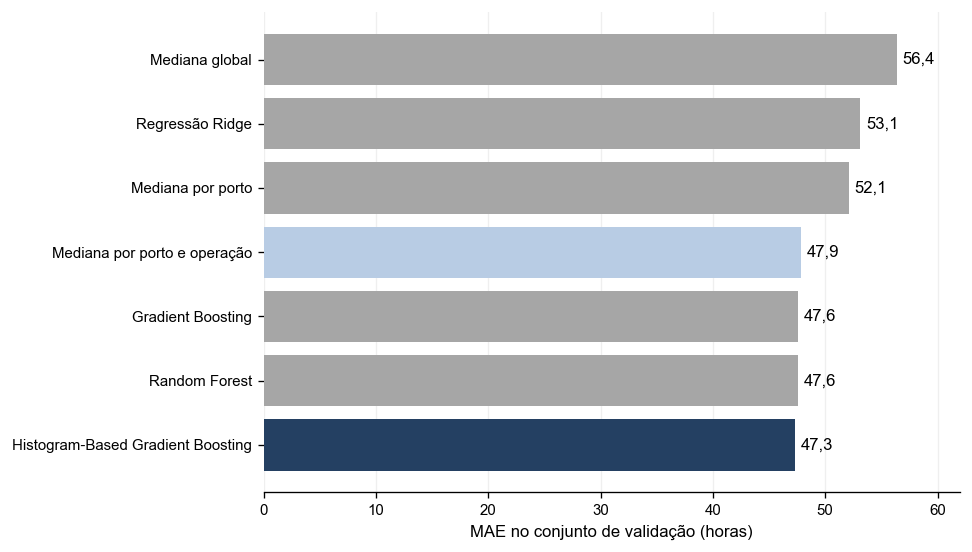

In [203]:
modelos = [
    "Mediana global",
    "Regressão Ridge",
    "Mediana por porto",
    "Mediana por porto e operação",
    "Gradient Boosting",
    "Random Forest",
    "Histogram-Based Gradient Boosting",
]

mae = [
    56.3633,
    53.1205,
    52.1019,
    47.8641,
    47.6074,
    47.5885,
    47.3037,
]

# Ordenar do maior para o menor erro
ordem = np.argsort(mae)[::-1]

modelos_plot = np.array(modelos)[ordem]
mae_plot = np.array(mae)[ordem]

fig, ax = plt.subplots(figsize=(8.2, 4.7))

cores = [
    AZUL_ESCURO if modelo == "Histogram-Based Gradient Boosting"
    else AZUL_CLARO if modelo == "Mediana por porto e operação"
    else CINZA
    for modelo in modelos_plot
]

bars = ax.barh(modelos_plot, mae_plot, color=cores)

ax.invert_yaxis()

ax.set_xlabel("MAE no conjunto de validação (horas)")
ax.set_xlim(0, 62)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", alpha=0.20)
ax.set_axisbelow(True)

# Valores ao lado das barras
for bar, valor in zip(bars, mae_plot):
    ax.text(
        valor + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:.1f}".replace(".", ","),
        va="center"
    )

finalizar_grafico(
    fig,
    "comparacao_mae_modelos_pontuais.png"
)

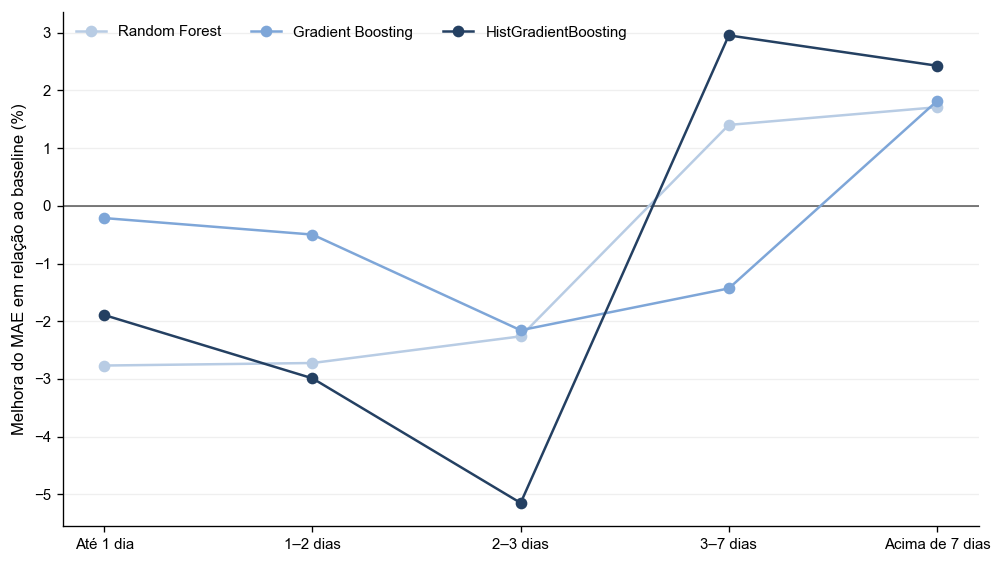

In [196]:
faixas = [
    "Até 1 dia",
    "1–2 dias",
    "2–3 dias",
    "3–7 dias",
    "Acima de 7 dias"
]

baseline = np.array([
    15.350232,
    17.758977,
    19.777192,
    47.296609,
    241.527728
])

random_forest = np.array([
    15.774986,
    18.242598,
    20.224432,
    46.633024,
    237.398330
])

gradient_boosting = np.array([
    15.382689,
    17.847296,
    20.203502,
    47.973121,
    237.141886
])

hist_gradient_boosting = np.array([
    15.640669,
    18.289811,
    20.795470,
    45.899005,
    235.659671
])

# Ganho positivo = modelo melhor que baseline
ganho_rf = (baseline - random_forest) / baseline * 100
ganho_gb = (baseline - gradient_boosting) / baseline * 100
ganho_hgb = (baseline - hist_gradient_boosting) / baseline * 100

x = np.arange(len(faixas))

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.axhline(0, linewidth=1, color="black", alpha=0.6)

ax.plot(
    x, ganho_rf,
    marker="o",
    label="Random Forest",
    color=AZUL_CLARO
)

ax.plot(
    x, ganho_gb,
    marker="o",
    label="Gradient Boosting",
    color=AZUL_MEDIO
)

ax.plot(
    x, ganho_hgb,
    marker="o",
    label="HistGradientBoosting",
    color=AZUL_ESCURO
)

ax.set_xticks(x)
ax.set_xticklabels(faixas)

ax.set_ylabel("Melhora do MAE em relação ao baseline (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.20)
ax.set_axisbelow(True)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper left"
)

finalizar_grafico(
    fig,
    "ganho_mae_por_faixa_permanencia.png"
)

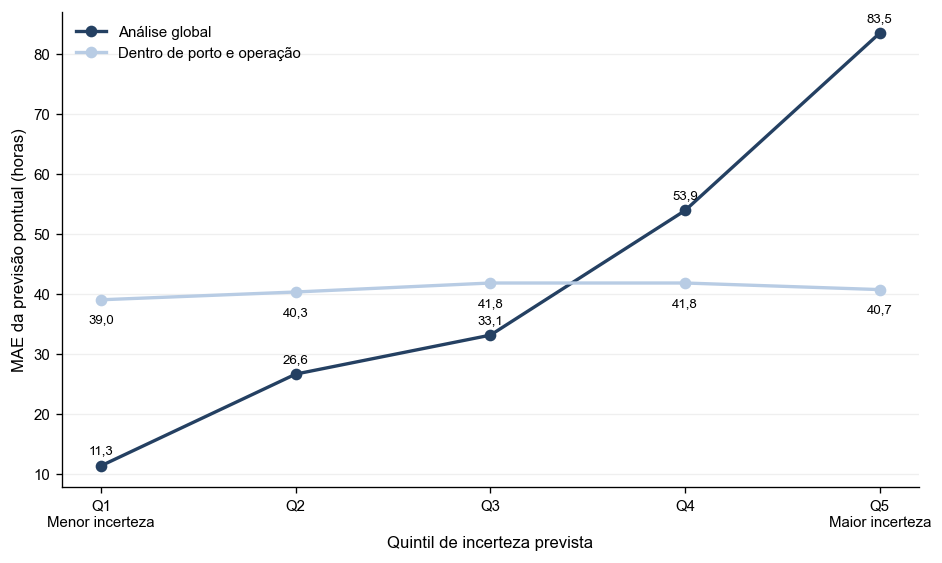

In [197]:
quintis = ["Q1", "Q2", "Q3", "Q4", "Q5"]

mae_global = [
    11.3,
    26.6,
    33.1,
    53.9,
    83.5
]

mae_intragrupo = [
    39.0,
    40.3,
    41.8,
    41.8,
    40.7
]

x = np.arange(len(quintis))

fig, ax = plt.subplots(figsize=(8.0, 4.8))

ax.plot(
    x,
    mae_global,
    marker="o",
    linewidth=2,
    label="Análise global",
    color=AZUL_ESCURO
)

ax.plot(
    x,
    mae_intragrupo,
    marker="o",
    linewidth=2,
    label="Dentro de porto e operação",
    color=AZUL_CLARO
)

ax.set_xticks(x)
ax.set_xticklabels([
    "Q1\nMenor incerteza",
    "Q2",
    "Q3",
    "Q4",
    "Q5\nMaior incerteza"
])

ax.set_ylabel("MAE da previsão pontual (horas)")
ax.set_xlabel("Quintil de incerteza prevista")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.20)
ax.set_axisbelow(True)

ax.legend(frameon=False)

# Mostrar valores
for xi, valor in zip(x, mae_global):
    ax.annotate(
        f"{valor:.1f}".replace(".", ","),
        (xi, valor),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

for xi, valor in zip(x, mae_intragrupo):
    ax.annotate(
        f"{valor:.1f}".replace(".", ","),
        (xi, valor),
        xytext=(0, -14),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

finalizar_grafico(
    fig,
    "incerteza_global_vs_intragrupo_mae.png"
)

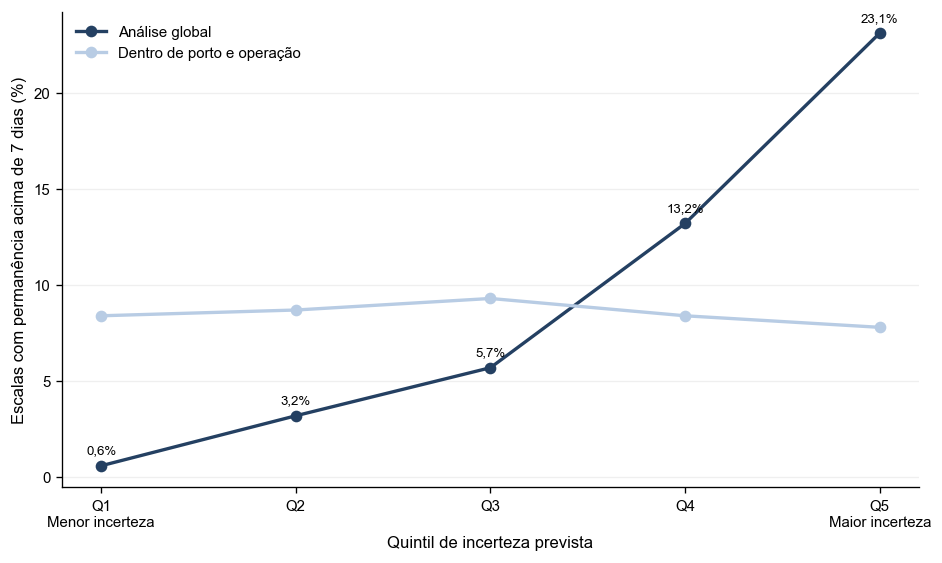

In [198]:
quintis = ["Q1", "Q2", "Q3", "Q4", "Q5"]

longos_global = [
    0.6,
    3.2,
    5.7,
    13.2,
    23.1
]

longos_intragrupo = [
    8.4,
    8.7,
    9.3,
    8.4,
    7.8
]

x = np.arange(len(quintis))

fig, ax = plt.subplots(figsize=(8.0, 4.8))

ax.plot(
    x,
    longos_global,
    marker="o",
    linewidth=2,
    label="Análise global",
    color=AZUL_ESCURO
)

ax.plot(
    x,
    longos_intragrupo,
    marker="o",
    linewidth=2,
    label="Dentro de porto e operação",
    color=AZUL_CLARO
)

ax.set_xticks(x)
ax.set_xticklabels([
    "Q1\nMenor incerteza",
    "Q2",
    "Q3",
    "Q4",
    "Q5\nMaior incerteza"
])

ax.set_ylabel("Escalas com permanência acima de 7 dias (%)")
ax.set_xlabel("Quintil de incerteza prevista")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.20)
ax.set_axisbelow(True)

ax.legend(frameon=False)

for xi, valor in zip(x, longos_global):
    ax.annotate(
        f"{valor:.1f}%".replace(".", ","),
        (xi, valor),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

finalizar_grafico(
    fig,
    "incerteza_global_vs_intragrupo_longas.png"
)

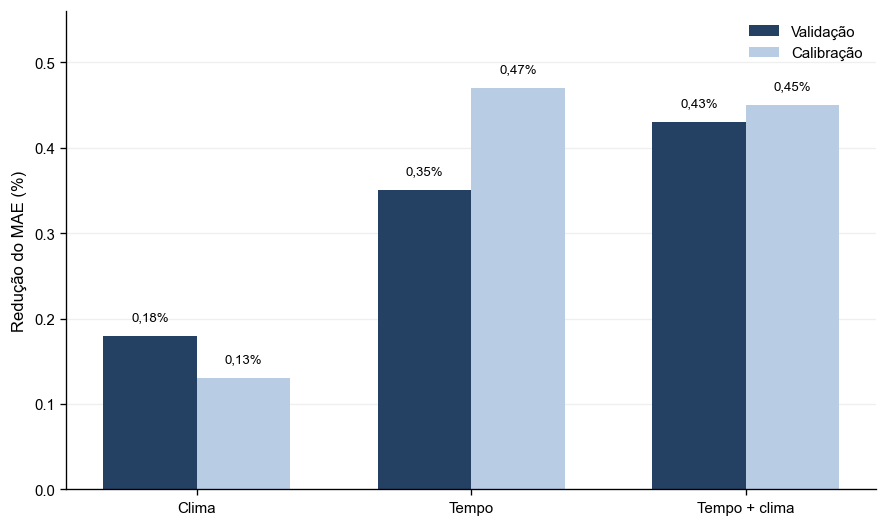

In [199]:
grupos = [
    "Clima",
    "Tempo",
    "Tempo + clima"
]

ganho_validacao = [
    0.18,
    0.35,
    0.43
]

ganho_calibracao = [
    0.13,
    0.47,
    0.45
]

x = np.arange(len(grupos))
largura = 0.34

fig, ax = plt.subplots(figsize=(7.5, 4.5))

bars1 = ax.bar(
    x - largura/2,
    ganho_validacao,
    largura,
    label="Validação",
    color=AZUL_ESCURO
)

bars2 = ax.bar(
    x + largura/2,
    ganho_calibracao,
    largura,
    label="Calibração",
    color=AZUL_CLARO
)

ax.set_xticks(x)
ax.set_xticklabels(grupos)

ax.set_ylabel("Redução do MAE (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.20)
ax.set_axisbelow(True)

ax.legend(frameon=False)

for bars in [bars1, bars2]:
    for bar in bars:
        valor = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            valor + 0.015,
            f"{valor:.2f}%".replace(".", ","),
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_ylim(0, 0.56)

finalizar_grafico(
    fig,
    "ganho_variaveis_contextuais.png"
)

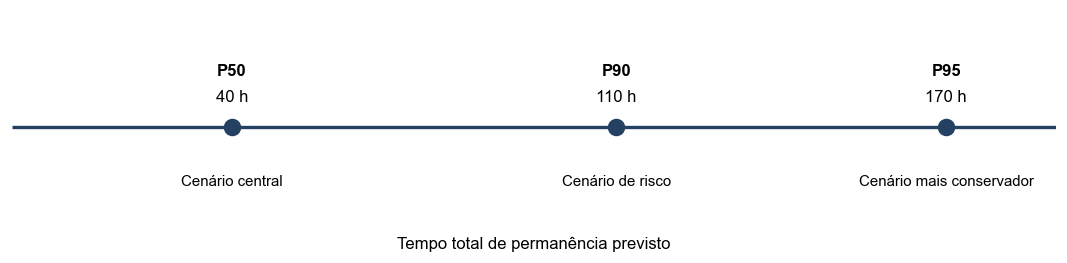

In [200]:
fig, ax = plt.subplots(figsize=(9, 2.3))

p50 = 40
p90 = 110
p95 = 170

# Linha principal
ax.hlines(
    y=0,
    xmin=0,
    xmax=190,
    linewidth=2,
    color=AZUL_ESCURO
)

# Pontos
valores = [p50, p90, p95]
labels = ["P50", "P90", "P95"]
descricoes = [
    "Cenário central",
    "Cenário de risco",
    "Cenário mais conservador"
]

for x, label, descricao in zip(valores, labels, descricoes):

    ax.scatter(
        x,
        0,
        s=90,
        color=AZUL_ESCURO,
        zorder=3
    )

    ax.text(
        x,
        0.17,
        label,
        ha="center",
        va="bottom",
        weight="bold"
    )

    ax.text(
        x,
        0.08,
        f"{x} h",
        ha="center",
        va="bottom"
    )

    ax.text(
        x,
        -0.16,
        descricao,
        ha="center",
        va="top",
        fontsize=9
    )

ax.set_xlim(0, 190)
ax.set_ylim(-0.35, 0.40)

ax.set_xlabel("Tempo total de permanência previsto")

ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)

# Não mostrar escala numérica do eixo para manter caráter esquemático
ax.set_xticks([])

finalizar_grafico(
    fig,
    "exemplo_previsao_quantilica.png"
)